# HybridDeepFilterNet — Complete Self-Contained Notebook

**Full pipeline (everything inline — no external src/ imports):**
```
Noisy Waveform
  ↓ Complex STFT  (n_fft=512, hop=160, win=400, Hann)
  ↓ Log-Power + Per-Sample Normalisation
  ↓ MobileOne Encoder   [32 → 64 → 128 ch]
  ↓ Conformer Lite x2   [d=128, heads=4]
  ↓ TF Attention        [SE + temporal + frequency]
  ↓ GRU Refinement      [hidden=256, 2 layers]
  ↓ Magnitude Mask Head [sigmoid, scalar per bin, range 0–2]
  ↓ DeepFilter K=5 Taps [tanh-bounded L2-magnitude norm, causal]
  ↓ Complex FIR Filter  [causal, no future leakage]
  ↓ ISTFT → Clean Waveform
```

**All fixes vs original notebook:**
- Everything self-contained (no src/ imports)
- End-to-end waveform loss (not spectrogram MSE)
- Deep filter taps actually trained & used
- AMP (mixed precision) truly enabled
- steps_per_epoch respected
- num_workers > 0 via spawn context (RTX 4060 optimised)
- Gradient accumulation (effective batch = 8 × 2 = 16)
- Data generation demo with spectrograms
- Speed & accuracy benchmark with charts


In [1]:
!pip install torch torchaudio numpy scipy librosa soundfile \
             matplotlib onnx onnxruntime tensorboard pystoi \
             pyroomacoustics kagglehub pyyaml tqdm ipywidgets pesq speechmos tqdm ipywidgets --quiet

try:
    import pesq
    print('[ok] PESQ available')
except ImportError:
    print('[note] PESQ not available — run: pip install pesq')

[ok] PESQ available


In [2]:
"""import librosa
import soundfile as sf
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def resample_dataset_fast(input_dir, output_dir, target_sr=16000):
    in_dir = Path(input_dir)
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # Grab all audio files
    exts = {".wav", ".flac", ".ogg", ".mp3", ".m4a"}
    files = [p for p in in_dir.rglob("*") if p.is_file() and p.suffix.lower() in exts]
    
    if not files:
        print(f"No files found in {in_dir}")
        return

    print(f"Converting {len(files)} files to {target_sr}Hz Mono...")
    
    for f in tqdm(files):
        # librosa automatically handles resampling and downmixing to mono
        y, _ = librosa.load(f, sr=target_sr, mono=True)
        
        # Keep the exact same folder structure
        rel_path = f.relative_to(in_dir)
        save_path = out_dir / rel_path
        
        # Force it to be a .wav file for fastest loading during training
        save_path = save_path.with_suffix('.wav')
        save_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Save as standard 16-bit PCM WAV
        sf.write(save_path, y, target_sr, subtype='PCM_16')
        
    print(f"Done! New dataset saved to: {out_dir}")

# 1. Convert your Clean data
resample_dataset_fast(
    input_dir=r"E:\0. Noise reduce\data\clean", 
    output_dir=r"E:\0. Noise reduce\data\clean_16k"
)

# 2. Convert your Noise data
resample_dataset_fast(
    input_dir=r"E:\0. Noise reduce\denoise-audio\data\processed\noise_realtime", 
    output_dir=r"E:\0. Noise reduce\data\noise_16k"
)"""

'import librosa\nimport soundfile as sf\nfrom pathlib import Path\nfrom tqdm.notebook import tqdm\nimport warnings\nwarnings.filterwarnings(\'ignore\')\n\ndef resample_dataset_fast(input_dir, output_dir, target_sr=16000):\n    in_dir = Path(input_dir)\n    out_dir = Path(output_dir)\n    out_dir.mkdir(parents=True, exist_ok=True)\n    \n    # Grab all audio files\n    exts = {".wav", ".flac", ".ogg", ".mp3", ".m4a"}\n    files = [p for p in in_dir.rglob("*") if p.is_file() and p.suffix.lower() in exts]\n    \n    if not files:\n        print(f"No files found in {in_dir}")\n        return\n\n    print(f"Converting {len(files)} files to {target_sr}Hz Mono...")\n    \n    for f in tqdm(files):\n        # librosa automatically handles resampling and downmixing to mono\n        y, _ = librosa.load(f, sr=target_sr, mono=True)\n        \n        # Keep the exact same folder structure\n        rel_path = f.relative_to(in_dir)\n        save_path = out_dir / rel_path\n        \n        # Force i

In [3]:
import sys, os, json, math, time, random, warnings, multiprocessing
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict, Any, Sequence
from itertools import product

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import GradScaler
# tqdm.notebook renders properly in VS Code Jupyter (widget-based bars)
try:
    from tqdm.notebook import tqdm, trange
except ImportError:
    from tqdm import tqdm, trange
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=UserWarning)

# ── Project root ──────────────────────────────────────────────────────────────
ROOT = Path(r"E:\\0. Noise reduce")

# ── GPU optimisation for RTX 4060 ────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark    = True   # auto-tune kernels
    torch.backends.cudnn.deterministic = False  # speed > reproducibility
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

print(f"Device  : {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU     : {p.name}")
    print(f"VRAM    : {p.total_memory / 1e9:.1f} GB")
    print(f"SM count: {p.multi_processor_count}")
print(f"PyTorch : {torch.__version__}")
print(f"CPU cores: {multiprocessing.cpu_count()}")

# ── Windows multiprocessing — spawn context for num_workers > 0 ──────────────
# On Windows, DataLoader workers require 'spawn'. We set it once here.
if os.name == 'nt':
    try:
        multiprocessing.set_start_method('spawn', force=True)
    except RuntimeError:
        pass   # already set

Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.6 GB
SM count: 24
PyTorch : 2.5.1+cu121
CPU cores: 16


In [4]:
# ══════════════════════════════════════════════════════════════
# UTILITIES  (previously src/utils.py)
# ══════════════════════════════════════════════════════════════

def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def compute_rms(x: np.ndarray) -> float:
    x64 = x.astype(np.float64)
    return float(np.sqrt(np.mean(x64 * x64) + 1e-12))


def scale_noise_to_snr(clean: np.ndarray, noise: np.ndarray, snr_db: float) -> np.ndarray:
    rms_s        = compute_rms(clean)
    rms_n_raw    = compute_rms(noise) + 1e-12
    rms_n_target = rms_s / (10.0 ** (snr_db / 20.0))
    return noise * (rms_n_target / rms_n_raw)


def soft_clip(x: np.ndarray, threshold: float = 0.95) -> np.ndarray:
    t = float(threshold)
    return np.tanh(x / t) * t


def snr_db(clean: np.ndarray, test: np.ndarray) -> float:
    c, t   = clean.astype(np.float64), test.astype(np.float64)
    p_c    = float(np.mean(c * c) + 1e-12)
    p_err  = float(np.mean((t - c) ** 2) + 1e-12)
    return 10.0 * math.log10(p_c / p_err)


def list_audio_files(root: Path) -> List[str]:
    exts  = {".wav", ".flac", ".ogg", ".mp3", ".m4a"}
    paths = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts]
    return [str(p) for p in paths]


def load_audio_mono(path: str, sr: int) -> np.ndarray:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(path)
    try:
        import soundfile as sf
        y, orig_sr = sf.read(str(p), dtype="float32", always_2d=False)
        if y.ndim == 2:
            y = np.mean(y, axis=1).astype(np.float32)
    except Exception:
        # Fallback: scipy.io.wavfile — no librosa/numba JIT
        from scipy.io import wavfile
        orig_sr, y = wavfile.read(str(p))
        if y.ndim == 2: y = y.mean(axis=1)
        y = y.astype(np.float32)
        if y.max() > 1.0: y = y / 32768.0
    if orig_sr != sr:
        # Always scipy — avoids librosa/numba JIT in DataLoader workers
        from scipy.signal import resample_poly
        g = math.gcd(int(orig_sr), int(sr))
        y = resample_poly(y, sr // g, orig_sr // g).astype(np.float32)
    return y


def crop_or_repeat(x: np.ndarray, length: int, rng: np.random.RandomState) -> np.ndarray:
    if x.size == length:
        return x
    if x.size > length:
        start = int(rng.randint(0, x.size - length + 1))
        return x[start: start + length]
    return np.tile(x, int(np.ceil(length / x.size)))[:length]


def peak_normalize(x: np.ndarray, peak: float = 0.99) -> np.ndarray:
    return x * (float(peak) / (float(np.max(np.abs(x)) + 1e-12)))


def save_manifest(entries: Sequence[Dict[str, Any]], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for e in entries:
            f.write(json.dumps(e, ensure_ascii=False) + "\n")


def load_manifest(path: Path) -> List[Dict[str, Any]]:
    entries = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                entries.append(json.loads(line))
    return entries


def generate_val_manifest(
    clean_list: List[str], noise_list: List[str],
    out_path: Path, n_val: int = 500,
    seed: int = 42, segment_len: float = 4.0,
) -> Path:
    rng = np.random.RandomState(seed)
    entries = []
    for i in range(int(n_val)):
        clean_path  = clean_list[int(rng.randint(0, len(clean_list)))]
        n_noise     = int(rng.randint(1, 4))
        noise_paths = [noise_list[int(rng.randint(0, len(noise_list)))] for _ in range(n_noise)]
        item_seed   = int(rng.randint(0, 2**31 - 1))
        entries.append({
            "id": i, "clean_path": clean_path, "noise_paths": noise_paths,
            "seed": item_seed, "segment_len": float(segment_len),
        })
    save_manifest(entries, out_path)
    return out_path


print("[ok] Utilities loaded.")

[ok] Utilities loaded.


In [ ]:
# ══════════════════════════════════════════════════════════════
# AUGMENTATION  (previously src/augment.py)
# ══════════════════════════════════════════════════════════════

def _butter_bandpass(x, sr, low_hz, high_hz):
    from scipy.signal import butter, sosfilt
    nyq = 0.5 * sr
    lo  = None if low_hz  is None else max(5.0,  float(low_hz)  / nyq)
    hi  = None if high_hz is None else min(0.999, float(high_hz) / nyq)
    if lo is None and hi is None: return x
    if lo is None:  sos = butter(4, hi,       btype="lowpass",  output="sos")
    elif hi is None: sos = butter(4, lo,      btype="highpass", output="sos")
    else:
        if lo >= hi: return x
        sos = butter(4, [lo, hi], btype="bandpass", output="sos")
    return sosfilt(sos, x).astype(np.float32)


def _add_hum(x, sr, rng):
    if rng.rand() > 0.25: return x, {"hum": None}
    freq = 50.0 if rng.rand() < 0.5 else 60.0
    amp  = float(rng.uniform(1e-4, 5e-3))
    t    = np.arange(x.size, dtype=np.float32) / float(sr)
    return (x + amp * np.sin(2.0 * np.pi * freq * t)).astype(np.float32), {"hum": {"freq": freq, "amp": amp}}


def _maybe_time_or_pitch_perturb(noise, sr, rng):
    """Scipy-based time stretch — no librosa/numba JIT in workers.
    Note: only time-stretching is implemented; pitch_shift is not used."""
    meta = {"time_stretch": None, "pitch_shift": None}
    if rng.rand() > 0.35: return noise, meta
    try:
        from scipy.signal import resample
        rate    = float(rng.uniform(0.95, 1.05))
        new_len = int(len(noise) / rate)
        y       = resample(noise.astype(np.float32), new_len).astype(np.float32)
        meta["time_stretch"] = rate
        return y, meta
    except Exception:
        return noise, meta


def _convolve_rir(clean, rir):
    from scipy.signal import fftconvolve
    y     = fftconvolve(clean.astype(np.float32), rir.astype(np.float32), mode="full")[:clean.size]
    rms_i = compute_rms(clean)
    rms_o = compute_rms(y)
    if rms_o > 0: y = y * (rms_i / (rms_o + 1e-12))
    return y.astype(np.float32)


def _generate_synthetic_rir(sr, rng):
    t60    = float(rng.uniform(0.08, 0.8))
    length = int(min(sr * 1.0, max(sr * 0.2, sr * (t60 * 1.2))))
    t      = np.arange(length, dtype=np.float32) / float(sr)
    decay  = np.exp(-6.91 * t / max(t60, 1e-3)).astype(np.float32)
    rir    = (rng.randn(length).astype(np.float32) * decay)
    rir[0] += 1.0
    return (rir / (np.max(np.abs(rir)) + 1e-12)).astype(np.float32)


def load_or_generate_rir(project_root, sr, rng):
    try:
        import pyroomacoustics as pra
        room_dim  = rng.uniform([3.0,3.0,2.3],[9.0,7.0,3.2]).tolist()
        t60       = float(rng.uniform(0.08, 0.8))
        abs_c, mo = pra.inverse_sabine(t60, room_dim)
        room      = pra.ShoeBox(room_dim, fs=sr, materials=pra.Material(abs_c), max_order=mo)
        mic = rng.uniform([0.5,0.5,1.0],[room_dim[0]-0.5,room_dim[1]-0.5,1.6]).tolist()
        src = rng.uniform([0.5,0.5,1.0],[room_dim[0]-0.5,room_dim[1]-0.5,1.8]).tolist()
        room.add_microphone_array(np.array(mic,dtype=np.float32).reshape(3,1))
        room.add_source(np.array(src,dtype=np.float32))
        room.compute_rir()
        rir = np.asarray(room.rir[0][0],dtype=np.float32)
        rir = rir / (np.max(np.abs(rir)) + 1e-12)
        return rir, {"rir_source": "pyroomacoustics", "t60": t60}
    except Exception: pass

    rir_root = project_root / "data" / "rirs"
    if rir_root.exists():
        files = [p for p in rir_root.rglob("*") if p.suffix.lower() in {".wav",".flac"}]
        if files:
            pick = files[int(rng.randint(0, len(files)))]
            rir  = load_audio_mono(str(pick), sr=sr)
            rir  = rir[:int(sr*1.0)] / (np.max(np.abs(rir)) + 1e-12)
            return rir.astype(np.float32), {"rir_source":"dataset","path":str(pick)}

    return _generate_synthetic_rir(sr, rng), {"rir_source": "synthetic"}


def _apply_device_effects(x, sr, rng):
    meta = {"bandlimit": None, "clip": None, "soft_clip": None}
    if rng.rand() < 0.35:
        low  = float(rng.uniform(80.0,200.0)) if rng.rand()<0.2 else None
        high = float(rng.uniform(3000.0,7800.0))
        x    = _butter_bandpass(x, sr=sr, low_hz=low, high_hz=high)
        meta["bandlimit"] = {"low_hz": low, "high_hz": high}
    if rng.rand() < 0.12:
        thr  = float(rng.uniform(0.85,0.95))
        x    = np.clip(x,-thr,thr).astype(np.float32)
        x    = _butter_bandpass(x, sr=sr, low_hz=None, high_hz=7800.0)
        meta["clip"] = {"threshold": thr}
    if rng.rand() < 0.25:
        thr  = float(rng.uniform(0.90,0.99))
        x    = soft_clip(x, threshold=thr).astype(np.float32)
        meta["soft_clip"] = {"threshold": thr}
    return x.astype(np.float32), meta


def _sample_snr(rng, snr_config, time_varying):
    if "snr_db" in snr_config and snr_config["snr_db"] is not None and not time_varying:
        return float(snr_config["snr_db"])
    
    # FIX 1: Realistic DNS4 Challenge bounds (min=0, mode=15, max=40)
    return float(rng.triangular(0.0, 15.0, 40.0))

def mix_clean_with_noises(
    clean, noise_paths, sr, segment_len,
    snr_config, rir=None, time_varying=False, multi_noise=(1,3),
):
    rng    = np.random.RandomState(int(snr_config.get("seed", 0)))
    length = int(round(float(segment_len) * float(sr)))
    clean_seg = crop_or_repeat(clean.astype(np.float32), length, rng)
    meta   = {"seed": int(snr_config.get("seed",0)), "noise_files": [],
              "snr_db": None, "snr_db_segments": None, "rir": None, "aug": {}}

    # FIX 5: Dry Clean Target. 
    # RIR is applied ONLY to 'clean_reverb' to mix into the noisy signal.
    # The target ('clean_proc') remains strictly dry so the model learns to dereverb!
    clean_reverb = _convolve_rir(clean_seg, rir) if rir is not None else clean_seg
    clean_proc   = clean_seg 

    if rir is not None: meta["rir"] = {"provided": True, "len": int(rir.size)}

    n_min, n_max = int(multi_noise[0]), int(multi_noise[1])
    n_pick = int(rng.randint(n_min, n_max+1))
    chosen = [noise_paths[int(rng.randint(0, len(noise_paths)))] for _ in range(n_pick)]
    meta["noise_files"] = list(chosen)

    noise_sum, per_noise_meta = np.zeros_like(clean_seg, dtype=np.float32), []
    for p in chosen:
        n, pm = _maybe_time_or_pitch_perturb(load_audio_mono(p, sr=sr), sr=sr, rng=rng)
        n = crop_or_repeat(n.astype(np.float32), length, rng)
        if rng.rand() < 0.35:
            low  = float(rng.uniform(60.0,200.0)) if rng.rand()<0.15 else None
            high = float(rng.uniform(2500.0,7800.0))
            n = _butter_bandpass(n, sr=sr, low_hz=low, high_hz=high)
            pm["bandlimit"] = {"low_hz": low, "high_hz": high}
        gain_db = float(rng.uniform(-6.0, 6.0))
        n = n * (10.0 ** (gain_db / 20.0))
        pm["gain_db"] = gain_db
        per_noise_meta.append(pm)
        noise_sum = (noise_sum + n.astype(np.float32)).astype(np.float32)
    meta["aug"]["per_noise"] = per_noise_meta

    if time_varying:
        forced_list   = snr_config.get("vary_snr_db_list")
        forced_bounds = snr_config.get("vary_boundaries")
        if forced_list is not None and forced_bounds is not None:
            snr_list, bounds = [float(v) for v in forced_list], [int(b) for b in forced_bounds]
        else:
            n_seg   = int(rng.randint(2, 7))
            min_len = int(0.30 * sr)
            cuts    = sorted(rng.randint(min_len, length - min_len, size=n_seg-1).tolist())
            bounds  = [0] + cuts + [length]
            snr_list= [float(_sample_snr(rng, snr_config, True)) for _ in range(n_seg)]
        noise_scaled = np.zeros_like(noise_sum, dtype=np.float32)
        for i in range(len(snr_list)):
            a, b = bounds[i], bounds[i+1]
            # Scale relative to reverbed clean, not dry!
            noise_scaled[a:b] = scale_noise_to_snr(clean_reverb[a:b], noise_sum[a:b], snr_list[i])
        meta["snr_db_segments"] = {"bounds": bounds, "snr_db": snr_list}
        meta["snr_db"] = float(np.mean(snr_list))
        noisy = (clean_reverb + noise_scaled).astype(np.float32)
    else:
        db    = float(_sample_snr(rng, snr_config, False))
        meta["snr_db"] = db
        noisy = (clean_reverb + scale_noise_to_snr(clean_reverb, noise_sum, db)).astype(np.float32)

    noisy, hum_meta = _add_hum(noisy, sr=sr, rng=rng)
    meta["aug"]["hum"] = hum_meta["hum"]
    noisy, dev_meta = _apply_device_effects(noisy, sr=sr, rng=rng)
    meta["aug"]["device"] = dev_meta

    fg = float(rng.uniform(-3.0, 3.0))
    noisy, clean_proc = noisy*(10**(fg/20)), clean_proc*(10**(fg/20))
    meta["aug"]["final_gain_db"] = fg

    if rng.rand() < 0.9:
        pk = float(rng.uniform(0.90, 0.99))
        scalar = pk / (float(np.max(np.abs(noisy))) + 1e-12)
        noisy      = (noisy * scalar).astype(np.float32)
        clean_proc = (clean_proc * scalar).astype(np.float32)
        meta["aug"]["peak_norm"] = pk
    if rng.rand() < 0.25:
        thr = float(rng.uniform(0.90, 0.98))
        noisy = soft_clip(noisy, threshold=thr).astype(np.float32)
        meta["aug"]["soft_clip_post"] = thr

    meta["clean_rms"] = compute_rms(clean_proc)
    meta["noisy_rms"] = compute_rms(noisy)
    return noisy.astype(np.float32), clean_proc.astype(np.float32), meta

print("[ok] Augmentation pipeline loaded.")

def build_rir_cache(project_root, sr: int, n_rirs: int = 500, seed: int = 42) -> list:
    """
    Pre-generate a pool of RIRs ONCE at startup.
    During training, __getitem__ picks a random one — zero compute cost.

    Args:
        project_root : Path to project root
        sr           : sample rate (16000)
        n_rirs       : how many RIRs to generate (500 is plenty)
        seed         : reproducibility seed

    Returns:
        List of np.ndarray RIRs, each shape (L,) float32
    """
    rng   = np.random.RandomState(seed)
    cache = []
    print(f"Building RIR cache ({n_rirs} rooms)...", end=" ", flush=True)
    t0 = time.time()
    for i in range(n_rirs):
        rir, _ = load_or_generate_rir(project_root, sr=sr, rng=rng)
        cache.append(rir)
    elapsed = time.time() - t0
    print(f"done in {elapsed:.1f}s  ({elapsed/n_rirs*1000:.0f}ms/RIR)")
    print(f"[ok] RIR cache ready: {n_rirs} rooms, "
          f"{sum(r.size for r in cache)*4/1024:.0f} KB RAM")
    return cache


[ok] Augmentation pipeline loaded.


In [6]:
# ══════════════════════════════════════════════════════════════
# MOBILEONE  (previously src/mobileone.py)
# ══════════════════════════════════════════════════════════════

def fuse_conv_bn(conv, bn):
    cb = torch.zeros(conv.weight.size(0), device=conv.weight.device, dtype=conv.weight.dtype) if conv.bias is None else conv.bias
    std   = torch.sqrt(bn.running_var + bn.eps)
    scale = (bn.weight / std).reshape(-1,1,1,1)
    return conv.weight * scale, bn.bias + (cb - bn.running_mean) * (bn.weight / std)


def _fuse_identity_bn(bn, num_channels, device, dtype):
    kernel = torch.zeros((num_channels,num_channels,3,3), device=device, dtype=dtype)
    idx    = torch.arange(num_channels, device=device)
    kernel[idx,idx,1,1] = 1.0
    rm = bn.running_mean.to(device=device,dtype=dtype)
    rv = bn.running_var.to(device=device,dtype=dtype)
    g  = bn.weight.to(device=device,dtype=dtype)
    b  = bn.bias.to(device=device,dtype=dtype)
    std   = torch.sqrt(rv + bn.eps)
    scale = (g / std).reshape(-1,1,1,1)
    return kernel * scale, b - rm * (g / std)


def _pad_1x1_to_3x3(k):
    return F.pad(k, [1,1,1,1])


@dataclass
class MobileOneConfig:
    in_channels:        int
    out_channels:       int
    stride:             int   = 1
    padding:            int   = 1
    dilation:           int   = 1
    groups:             int   = 1
    num_conv_branches:  int   = 1
    use_scale_branch:   bool  = True
    use_identity_branch:bool  = True
    activation:         str   = "silu"


class MobileOneBlock(nn.Module):
    def __init__(self, cfg: MobileOneConfig, inference_mode: bool = False):
        super().__init__()
        self.cfg = cfg
        self.inference_mode = inference_mode
        if cfg.groups != 1: raise ValueError("groups=1 only")
        act = cfg.activation.lower()
        self.act = nn.SiLU(inplace=True) if act=="silu" else (nn.ReLU(inplace=True) if act=="relu" else nn.Identity())

        if inference_mode:
            self.rbr_reparam = nn.Conv2d(cfg.in_channels, cfg.out_channels, 3,
                stride=cfg.stride, padding=cfg.padding, dilation=cfg.dilation, groups=cfg.groups, bias=True)
            self.rbr_conv = self.rbr_scale = self.rbr_identity = None
        else:
            self.rbr_conv = nn.ModuleList([self._conv_bn(3) for _ in range(cfg.num_conv_branches)])
            self.rbr_scale    = self._conv_bn(1) if cfg.use_scale_branch else None
            can_id = cfg.use_identity_branch and cfg.stride==1 and cfg.in_channels==cfg.out_channels
            self.rbr_identity = nn.BatchNorm2d(cfg.in_channels) if can_id else None
            self.rbr_reparam  = None

    def _conv_bn(self, ks):
        pad  = self.cfg.padding if ks==3 else 0
        conv = nn.Conv2d(self.cfg.in_channels, self.cfg.out_channels, ks,
                         stride=self.cfg.stride, padding=pad,
                         dilation=self.cfg.dilation, groups=self.cfg.groups, bias=False)
        return nn.Sequential(conv, nn.BatchNorm2d(self.cfg.out_channels))

    def forward(self, x):
        if self.inference_mode: return self.act(self.rbr_reparam(x))
        out = sum(b(x) for b in self.rbr_conv)
        if self.rbr_scale    is not None: out = out + self.rbr_scale(x)
        if self.rbr_identity is not None: out = out + self.rbr_identity(x)
        return self.act(out)

    @torch.no_grad()
    def get_equivalent_kernel_bias(self):
        if self.inference_mode:
            return self.rbr_reparam.weight, self.rbr_reparam.bias
        dev, dt = next(self.parameters()).device, next(self.parameters()).dtype
        K = torch.zeros((self.cfg.out_channels, self.cfg.in_channels, 3,3), device=dev, dtype=dt)
        B = torch.zeros((self.cfg.out_channels,), device=dev, dtype=dt)
        for b in self.rbr_conv:
            k, bs = fuse_conv_bn(b[0], b[1]); K, B = K+k, B+bs
        if self.rbr_scale:
            k1, b1 = fuse_conv_bn(self.rbr_scale[0], self.rbr_scale[1])
            K, B   = K + _pad_1x1_to_3x3(k1), B + b1
        if self.rbr_identity:
            ki, bi = _fuse_identity_bn(self.rbr_identity, self.cfg.in_channels, dev, dt)
            K, B   = K + ki, B + bi
        return K, B

    @torch.no_grad()
    def reparameterize(self):
        if self.inference_mode: return self
        kernel, bias = self.get_equivalent_kernel_bias()
        self.rbr_reparam = nn.Conv2d(self.cfg.in_channels, self.cfg.out_channels, 3,
            stride=self.cfg.stride, padding=self.cfg.padding,
            dilation=self.cfg.dilation, groups=self.cfg.groups, bias=True)
        self.rbr_reparam.weight.data.copy_(kernel)
        self.rbr_reparam.bias.data.copy_(bias)
        self.rbr_conv = self.rbr_scale = self.rbr_identity = None
        self.inference_mode = True
        return self


print("[ok] MobileOne blocks loaded.")

[ok] MobileOne blocks loaded.


In [7]:
# ══════════════════════════════════════════════════════════════
# DATASET  (previously src/dataset.py)
# ══════════════════════════════════════════════════════════════

class NoiseSuppressionDataset(Dataset):
    def __init__(self, clean_list, noise_list, segment_len=4.0, sr=16000,
                 mix_config=None, mode="train", manifest=None, rir_cache=None):
        self.clean_list  = list(clean_list)
        self.noise_list  = list(noise_list)
        self.segment_len = float(segment_len)
        self.sr          = int(sr)
        self.mix_config  = dict(mix_config or {})
        self.mode        = str(mode)
        self.manifest    = manifest

        if not self.clean_list:  raise ValueError("clean_list is empty.")
        if not self.noise_list:  raise ValueError("noise_list is empty.")
        if self.mode not in {"train","val"}: raise ValueError("mode must be train or val.")

        self.project_root = Path(self.mix_config.get("project_root", Path.cwd()))
        self._manifest_entries = None
        if self.mode == "val":
            if self.manifest is None: raise ValueError("Validation requires a manifest path.")
            self._manifest_entries = load_manifest(Path(self.manifest))
            if not self._manifest_entries: raise ValueError(f"Manifest empty: {self.manifest}")

        self.return_clean_spec = bool(self.mix_config.get("return_clean_spec", False))
        self.rir_cache = rir_cache  # pre-built list of np arrays or None

    def __len__(self):
        if self.mode == "val": return len(self._manifest_entries)
        return len(self.clean_list)

    def __getitem__(self, idx):
        base_seed = int(self.mix_config.get("seed", 42))
        if self.mode == "val":
            e          = self._manifest_entries[idx]
            clean_path = e["clean_path"]
            noise_paths= e["noise_paths"]
            item_seed  = int(e["seed"])
            seg_len    = float(e.get("segment_len", self.segment_len))
            rng        = np.random.RandomState(item_seed)
        else:
            rng        = np.random.RandomState(base_seed + idx)
            clean_path = self.clean_list[idx % len(self.clean_list)]
            n_noise    = int(rng.randint(1, 4))
            noise_paths= [self.noise_list[int(rng.randint(0,len(self.noise_list)))] for _ in range(n_noise)]
            item_seed  = int(rng.randint(0, 2**31-1))
            seg_len    = self.segment_len

        clean     = load_audio_mono(clean_path, sr=self.sr)
        length    = int(round(seg_len * self.sr))
        clean_seg = crop_or_repeat(clean, length, rng)

        p_vary    = float(self.mix_config.get("p_vary", 0.4))
        time_vary = bool(rng.rand() < p_vary) if self.mode=="train" else bool(self.mix_config.get("val_time_vary", True))

        p_rir = float(self.mix_config.get("p_rir", 0.35))
        rir   = None
        use_rir = (self.mode=="train" and rng.rand()<p_rir) or \
                  (self.mode=="val" and self.mix_config.get("val_use_rir", True))
        if use_rir:
            if self.rir_cache:
                # Fast path: pick randomly from pre-built cache (~0.001ms)
                rir = self.rir_cache[int(rng.randint(0, len(self.rir_cache)))]
            else:
                # Slow fallback: generate live (only if no cache provided)
                rir, _ = load_or_generate_rir(self.project_root, sr=self.sr, rng=rng)

        snr_cfg = {**self.mix_config, "seed": item_seed, "project_root": self.project_root}
        noisy, clean_proc, meta = mix_clean_with_noises(
            clean=clean_seg, noise_paths=list(noise_paths),
            sr=self.sr, segment_len=seg_len, snr_config=snr_cfg,
            rir=rir, time_varying=time_vary, multi_noise=(1,3),
        )
        return {
            "clean": torch.from_numpy(clean_proc).float(),
            "noisy": torch.from_numpy(noisy).float(),
            "meta":  meta,
        }


print("[ok] Dataset class loaded.")

[ok] Dataset class loaded.


In [8]:
# ══════════════════════════════════════════════════════════════
# MODEL — HybridDenoiser
# ══════════════════════════════════════════════════════════════

@dataclass
class HybridDenoiserConfig:
    n_fft:                int   = 512
    hop_length:           int   = 160
    win_length:           int   = 400
    enc_stages:           tuple = (32, 64, 128)
    num_blocks_per_stage: int   = 2
    activation:           str   = "silu"
    num_conformer_blocks: int   = 2
    conformer_heads:      int   = 4
    conformer_ffn_dim:    int   = 256
    conformer_conv_kernel:int   = 31
    dropout:              float = 0.1
    gru_hidden:           int   = 256
    gru_layers:           int   = 2
    k_tap:                int   = 5
    sr:                   int   = 16000

    @property
    def freq_bins(self):  return self.n_fft // 2 + 1
    @property
    def enc_out_ch(self): return self.enc_stages[-1]


def _act(name):
    return nn.SiLU(inplace=True) if name=="silu" else nn.ReLU(inplace=True)


class DSConv2d(nn.Module):
    def __init__(self, ch, act="silu"):
        super().__init__()
        self.dw=nn.Conv2d(ch,ch,3,padding=1,groups=ch,bias=False); self.dw_bn=nn.BatchNorm2d(ch)
        self.pw=nn.Conv2d(ch,ch,1,bias=False); self.pw_bn=nn.BatchNorm2d(ch)
        self.act=_act(act)
    def forward(self,x):
        return self.act(self.pw_bn(self.pw(self.act(self.dw_bn(self.dw(x))))))


class EncoderStage(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks, act):
        super().__init__()
        blocks = []
        for i in range(n_blocks):
            ic = in_ch if i==0 else out_ch
            blocks.append(MobileOneBlock(MobileOneConfig(
                in_channels=ic, out_channels=out_ch, stride=1, padding=1,
                num_conv_branches=2, use_scale_branch=True,
                use_identity_branch=(ic==out_ch), activation=act,
            ), inference_mode=False))
        blocks.append(DSConv2d(out_ch, act=act))
        self.seq = nn.Sequential(*blocks)
    def forward(self,x): return self.seq(x)


class _FFN(nn.Module):
    def __init__(self,d,inner,drop):
        super().__init__()
        self.norm=nn.LayerNorm(d); self.fc1=nn.Linear(d,inner)
        self.act=nn.SiLU(); self.drop=nn.Dropout(drop)
        self.fc2=nn.Linear(inner,d); self.drop2=nn.Dropout(drop)
    def forward(self,x):
        return x + 0.5*self.drop2(self.fc2(self.drop(self.act(self.fc1(self.norm(x))))))


class _ConvModule(nn.Module):
    def __init__(self,d,kernel,drop):
        super().__init__()
        self.norm=nn.LayerNorm(d); self.pw1=nn.Linear(d,d*2)
        self.dw=nn.Conv1d(d,d,kernel,padding=kernel//2,groups=d,bias=False)
        self.bn=nn.BatchNorm1d(d); self.act=nn.SiLU()
        self.pw2=nn.Linear(d,d); self.drop=nn.Dropout(drop)
    def forward(self,x):
        r=x; x=self.norm(x)
        x,g=self.pw1(x).chunk(2,dim=-1); x=x*g.sigmoid()
        x=self.act(self.bn(self.dw(x.transpose(1,2)))).transpose(1,2)
        return r+self.drop(self.pw2(x))


class ConformerLiteBlock(nn.Module):
    def __init__(self,d,heads,ffn_dim,conv_k,drop):
        super().__init__()
        self.ffn1=_FFN(d,ffn_dim,drop)
        self.norm_a=nn.LayerNorm(d)
        self.attn=nn.MultiheadAttention(d,heads,dropout=drop,batch_first=True)
        self.drop_a=nn.Dropout(drop)
        self.conv_m=_ConvModule(d,conv_k,drop)
        self.ffn2=_FFN(d,ffn_dim,drop)
        self.norm_o=nn.LayerNorm(d)
    def forward(self,x):
        x=self.ffn1(x); n=self.norm_a(x)
        a,_=self.attn(n,n,n); x=x+self.drop_a(a)
        x=self.conv_m(x); x=self.ffn2(x)
        return self.norm_o(x)


class TFAttentionBlock(nn.Module):
    def __init__(self,C,reduction=8,t_k=15,f_k=15):
        super().__init__()
        r=max(1,C//reduction)
        self.se_pool=nn.AdaptiveAvgPool2d(1)
        self.se_fc=nn.Sequential(nn.Flatten(),nn.Linear(C,r),nn.ReLU(inplace=True),nn.Linear(r,C),nn.Sigmoid())
        self.t_conv=nn.Conv1d(C,C,t_k,padding=t_k//2,groups=C,bias=False); self.t_bn=nn.BatchNorm1d(C)
        self.t_gate=nn.Conv2d(C,C,1,bias=False)
        self.f_conv=nn.Conv1d(C,C,f_k,padding=f_k//2,groups=C,bias=False); self.f_bn=nn.BatchNorm1d(C)
        self.f_gate=nn.Conv2d(C,C,1,bias=False)
        self.norm=nn.GroupNorm(min(8,C),C); self.act=nn.SiLU(inplace=True)
    def forward(self,x):
        res=x
        se=self.se_fc(self.se_pool(x)).view(x.shape[0],-1,1,1); x=x*se
        xt=self.act(self.t_bn(self.t_conv(x.mean(2)))).unsqueeze(2); x=x+self.t_gate(x*xt)
        xf=self.act(self.f_bn(self.f_conv(x.mean(3)))).unsqueeze(3); x=x+self.f_gate(x*xf)
        return self.norm(x+res)


class GRURefinement(nn.Module):
    def __init__(self,C,hidden,n_layers):
        super().__init__()
        self.proj_in=nn.Linear(C,hidden)
        self.gru=nn.GRU(hidden,hidden,num_layers=n_layers,batch_first=True)
        self.proj_out=nn.Linear(hidden,C); self.norm=nn.LayerNorm(C)
    def forward(self,x,h=None):
        xp=x.mean(2).transpose(1,2)
        y,h2=self.gru(self.proj_in(xp),h)
        ctx=self.norm(self.proj_out(y)).transpose(1,2).unsqueeze(2)
        return x+ctx, h2


class HybridDenoiser(nn.Module):
    def __init__(self, cfg=None):
        super().__init__()
        self.cfg = cfg or HybridDenoiserConfig()
        C, drop = self.cfg.enc_out_ch, self.cfg.dropout
        self.register_buffer('window', torch.hann_window(self.cfg.win_length))

        first_ch = self.cfg.enc_stages[0]
        self.in_proj = nn.Sequential(
            nn.Conv2d(1,first_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(first_ch), _act(self.cfg.activation),
        )
        stages, prev = [], first_ch
        for ch in self.cfg.enc_stages:
            stages.append(EncoderStage(prev,ch,self.cfg.num_blocks_per_stage,self.cfg.activation))
            prev=ch
        self.encoder = nn.Sequential(*stages)

        self.conformer = nn.Sequential(*[
            ConformerLiteBlock(C,self.cfg.conformer_heads,self.cfg.conformer_ffn_dim,
                               self.cfg.conformer_conv_kernel, drop)
            for _ in range(self.cfg.num_conformer_blocks)
        ])
        self.conf_proj = nn.Linear(C,C)
        self.tf_attn   = TFAttentionBlock(C)
        self.gru_refine= GRURefinement(C,self.cfg.gru_hidden,self.cfg.gru_layers)

        # Magnitude mask: Sigmoid [0,1] — proper noise suppression
        self.mask_mag_head = nn.Sequential(
            nn.Conv2d(C, C//2, 1, bias=False), _act(self.cfg.activation),
            nn.Conv2d(C//2, 1, 1), nn.Sigmoid(),
        )

        # Complex taps: 2*K channels (real + imag)
        self.tap_head = nn.Sequential(
            nn.Conv2d(C, C//2, 1, bias=False), _act(self.cfg.activation),
            nn.Conv2d(C//2, self.cfg.k_tap * 2, 1),
        )

    def _stft(self,wav):
        spec   = torch.stft(wav, self.cfg.n_fft, self.cfg.hop_length, self.cfg.win_length,
                            window=self.window, return_complex=True, center=True, pad_mode='reflect')
        mag    = spec.abs().clamp(min=1e-8)
        log_p  = 20.0 * torch.log10(mag)
        mean   = log_p.mean(dim=(-2,-1),keepdim=True)
        std    = log_p.std(dim=(-2,-1),keepdim=True).clamp(min=1e-8)
        feats  = ((log_p-mean)/std).unsqueeze(1)
        return spec, feats

    def _istft(self,spec,length):
        return torch.istft(spec, self.cfg.n_fft, self.cfg.hop_length, self.cfg.win_length,
                           window=self.window, length=length, center=True)

    @staticmethod
    def _deep_filter(spec, taps_real, taps_imag):
        """Complex FIR: (a+jb)(c+jd) = (ac-bd) + j(ad+bc)"""
        K  = taps_real.shape[2]
        sr = F.pad(spec.real, (K-1, 0))
        si = F.pad(spec.imag, (K-1, 0))
        wr = sr.unfold(-1, K, 1)
        wi = si.unfold(-1, K, 1)
        tr = taps_real.permute(0, 1, 3, 2)
        ti = taps_imag.permute(0, 1, 3, 2)
        out_real = (wr * tr - wi * ti).sum(-1)
        out_imag = (wr * ti + wi * tr).sum(-1)
        return torch.complex(out_real, out_imag)

    def forward(self,waveform,h=None):
        L = waveform.shape[-1]
        spec, feats = self._stft(waveform)
        x = self.encoder(self.in_proj(feats))
        x_pool = x.mean(2).transpose(1,2)
        ctx = self.conf_proj(self.conformer(x_pool))
        x   = x + ctx.transpose(1,2).unsqueeze(2)
        x   = self.tf_attn(x)
        x, h_new = self.gru_refine(x,h)
        
        # 1. Coarse Magnitude Mask (Allows volume boosting up to 2.0)
        mag_mask = self.mask_mag_head(x).squeeze(1).float() * 2.0

        # 2. Complex taps calculation
        taps_raw = self.tap_head(x).permute(0, 2, 1, 3).float()
        K = self.cfg.k_tap
        
        tap_mag = torch.sqrt(taps_raw[:, :, :K, :]**2 + taps_raw[:, :, K:, :]**2 + 1e-8)
        scale = (2.0 * torch.tanh(tap_mag)) / tap_mag
        
        taps_real = taps_raw[:, :, :K, :] * scale
        taps_imag = taps_raw[:, :, K:, :] * scale

        # THE SOTA FIX: Band-Split Phase Processing (DeepFilterNet Section 2.1)
        # At 16kHz (Nyquist 8kHz), 257 bins total. 5kHz is exactly bin 160.
        df_bins = 160 
        
        # --- LOW FREQUENCIES (0 to 5kHz): Complex Filtering ---
        # We inject the magnitude mask into the present tap ONLY for the low frequencies
        identity_low = torch.zeros_like(taps_real[:, :df_bins, :, :])
        identity_low[:, :, K-1, :] = mag_mask[:, :df_bins, :]  
        
        taps_real_low = taps_real[:, :df_bins, :, :] + identity_low
        taps_imag_low = taps_imag[:, :df_bins, :, :]
        
        low_spec = self._deep_filter(spec[:, :df_bins, :], taps_real_low, taps_imag_low)
        
        # --- HIGH FREQUENCIES (5kHz to 8kHz): Magnitude Mask Only ---
        # Phase above 5kHz is pure chaos. We scale the magnitude but KEEP the original noisy phase.
        high_spec = spec[:, df_bins:, :] * mag_mask[:, df_bins:, :]

        # Combine them back into a full 257-bin complex spectrogram!
        denoised_spec = torch.cat([low_spec, high_spec], dim=1)

        # 5. Inverse STFT
        denoised_wav  = self._istft(denoised_spec, length=L)
        taps_combined = torch.stack([taps_real, taps_imag], dim=-1).norm(dim=-1)
        
        return denoised_wav, taps_combined, h_new
    @torch.no_grad()
    def reparameterize(self):
        for m in self.modules():
            if isinstance(m, MobileOneBlock): m.reparameterize()
        return self


# ── Quick sanity check ────────────────────────────────────────────────────────
model_cfg = HybridDenoiserConfig(
    enc_stages=(64, 128, 256),  # 2x wider — better features
    num_blocks_per_stage=2,
    num_conformer_blocks=2,
    conformer_ffn_dim=512,
    conformer_heads=4,
    gru_hidden=512,
    gru_layers=2,
    k_tap=5,
    # VRAM: batch=8 × seg=3.0s × this model ≈ 4.3GB ✅ safe for 7.9GB
)
_tmp = HybridDenoiser(model_cfg).to(device)
n_params = sum(p.numel() for p in _tmp.parameters())
print(f"Parameters : {n_params:,}  (~{n_params/1e6:.2f} M)")
with torch.no_grad():
    _d = torch.randn(2,16000).to(device)
    _w, _t, _ = _tmp(_d)
    print(f"Input  : {_d.shape}  →  Output wav: {_w.shape}  |  Taps: {_t.shape}")
del _tmp; torch.cuda.empty_cache()
print("[ok] Model architecture verified.")

Parameters : 8,289,067  (~8.29 M)
Input  : torch.Size([2, 16000])  →  Output wav: torch.Size([2, 16000])  |  Taps: torch.Size([2, 257, 5, 101])
[ok] Model architecture verified.


In [ ]:
# ══════════════════════════════════════════════════════════════
# LOSS FUNCTIONS
# ══════════════════════════════════════════════════════════════
# NOTE: MultiResoSTFTLoss is defined here for reference but is NOT used
# during training or evaluation. HybridLoss is the sole training criterion.
class MultiResoSTFTLoss(nn.Module):
    RESOLUTIONS = [(512,160,400),(1024,320,800),(2048,512,2048)]
    def __init__(self):
        super().__init__()
        for i,(_,_,w) in enumerate(self.RESOLUTIONS):
            self.register_buffer(f'win_{i}', torch.hann_window(w))
    def forward(self,pred,target):
        loss = pred.new_zeros(1)
        for i,(n_fft,hop,win_len) in enumerate(self.RESOLUTIONS):
            win = getattr(self,f'win_{i}')
            kw  = dict(n_fft=n_fft,hop_length=hop,win_length=win_len,window=win,return_complex=True)
            pm  = torch.stft(pred.float(),**kw).abs()
            tm  = torch.stft(target.float(),**kw).abs()
            loss= loss + F.l1_loss(torch.log1p(pm),torch.log1p(tm))
        return loss / len(self.RESOLUTIONS)


class HybridLoss(nn.Module):
    def __init__(self, tap_reg_weight=1e-4, n_fft=512, hop=160, win=400):
        super().__init__()
        self.tap_reg_weight = tap_reg_weight
        self.n_fft = n_fft
        self.hop = hop
        self.win = win
        # Keep window on correct GPU device
        self.register_buffer('window', torch.hann_window(win))
        
    def forward(self, pred_wav, clean_wav, taps):
        # 1. STFT Conversion
        P_spec = torch.stft(pred_wav, self.n_fft, self.hop, self.win, window=self.window, return_complex=True, center=True, pad_mode='reflect')
        C_spec = torch.stft(clean_wav, self.n_fft, self.hop, self.win, window=self.window, return_complex=True, center=True, pad_mode='reflect')
        
        # 2. Power Compression (c=0.3)
        c = 0.3
        P_mag = P_spec.abs().clamp(min=1e-8)
        C_mag = C_spec.abs().clamp(min=1e-8)
        
        # 3. THE SOTA FIX: Asymmetric Compressed Magnitude Loss
        mag_diff = (P_mag ** c) - (C_mag ** c)
        # If P_mag < C_mag (meaning the AI cut the speech too aggressively), 
        # we multiply the penalty by 2.0 to force it to stop muffling the voice!
        mag_loss = torch.where(mag_diff < 0, mag_diff.abs() * 2.0, mag_diff.abs()).mean()
        
        # 4. Compressed Complex Loss (Strictly enforces phase and timing)
        P_comp = (P_mag ** c) * torch.exp(1j * P_spec.angle())
        C_comp = (C_mag ** c) * torch.exp(1j * C_spec.angle())
        comp_loss = F.l1_loss(P_comp.real, C_comp.real) + F.l1_loss(P_comp.imag, C_comp.imag)
        
        # 5. Tap Regularization
        tap_reg = taps.abs().mean()
        
        # mag_loss and comp_loss are weighted equally (1.0 each)
        total = mag_loss + comp_loss + (self.tap_reg_weight * tap_reg)
        
        return total, {'mag': mag_loss.item(), 'comp_complex': comp_loss.item(),
                       'tap_reg': tap_reg.item(), 'total': total.item()}
criterion_test = HybridLoss().to(device)
l,d = criterion_test(torch.randn(2,16000,device=device),
                     torch.randn(2,16000,device=device),
                     torch.randn(2,257,5,100,device=device))
print("Loss test:", {k:f'{v:.4f}' for k,v in d.items()})
print("[ok] Loss functions loaded.")

Loss test: {'mag': '0.5956', 'comp_complex': '3.2674', 'tap_reg': '0.7987', 'total': '3.8631'}
[ok] Loss functions loaded.


In [10]:
# ══════════════════════════════════════════════════════════════
# DATA GENERATION DEMO
# Mix clean + noise at various SNRs — show spectrograms
# ══════════════════════════════════════════════════════════════
import yaml

ROOT = Path(r"E:\\0. Noise reduce")
base_cfg    = yaml.safe_load((ROOT/"configs"/"train.yaml").read_text(encoding="utf-8"))
SR          = int(base_cfg['sr'])
SEG_LEN     = 3.0   # needs ≥2.5s for reliable PESQ wideband

clean_root = Path(r"E:\0. Noise reduce\data\clean_16k")
noise_root = Path(r"E:\0. Noise reduce\data\noise_16k")

clean_list = list_audio_files(clean_root)
noise_list = list_audio_files(noise_root)
print(f"#clean: {len(clean_list)}  |  #noise: {len(noise_list)}")

def make_spectrogram_db(wav, sr=16000, n_fft=512, hop=160, win=400):
    import scipy.signal
    _, _, Zxx = scipy.signal.stft(wav, fs=sr, nperseg=win,
                                   noverlap=win-hop, nfft=n_fft)
    return 20*np.log10(np.abs(Zxx)+1e-8)

def demo_mix(clean_path, noise_path, snr_targets=(-10, 0, 10, 20)):
    clean_wav = load_audio_mono(clean_path, SR)
    length    = int(SEG_LEN * SR)
    rng       = np.random.RandomState(0)
    clean_seg = crop_or_repeat(clean_wav, length, rng)

    fig, axes = plt.subplots(2, len(snr_targets)+1, figsize=(5*(len(snr_targets)+1), 6))

    # Column 0: clean
    spec_clean = make_spectrogram_db(clean_seg, SR)
    axes[0,0].imshow(spec_clean, origin='lower', aspect='auto',
                     extent=[0,SEG_LEN,0,SR//2/1000], vmin=-80, vmax=0, cmap='magma')
    axes[0,0].set_title('Clean'); axes[0,0].set_ylabel('Freq (kHz)')
    axes[1,0].plot(np.linspace(0,SEG_LEN,len(clean_seg)), clean_seg, lw=0.5)
    axes[1,0].set_title('Clean waveform'); axes[1,0].set_ylabel('Amplitude')
    axes[1,0].set_ylim(-1,1)

    for col, snr in enumerate(snr_targets, 1):
        noisy, _, meta = mix_clean_with_noises(
            clean=clean_seg, noise_paths=[noise_path], sr=SR,
            segment_len=SEG_LEN,
            snr_config={"seed":42,"snr_db":float(snr),"project_root":str(ROOT)},
            rir=None, time_varying=False, multi_noise=(1,1),
        )
        spec_noisy = make_spectrogram_db(noisy, SR)
        axes[0,col].imshow(spec_noisy, origin='lower', aspect='auto',
                           extent=[0,SEG_LEN,0,SR//2/1000], vmin=-80, vmax=0, cmap='magma')
        axes[0,col].set_title(f'Noisy  SNR={snr:+d} dB')
        axes[1,col].plot(np.linspace(0,SEG_LEN,len(noisy)), noisy, lw=0.5)
        axes[1,col].set_title(f'Waveform SNR={snr:+d} dB')
        axes[1,col].set_ylim(-1,1)

    for ax in axes.flatten():
        ax.set_xlabel('Time (s)')
    plt.suptitle('Data Generation Demo — Clean vs Noisy at Different SNRs', fontsize=13)
    plt.tight_layout()
    out_path = ROOT / 'data_demo.png'
    plt.savefig(str(out_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out_path}")

if clean_list and noise_list:
    demo_mix(clean_list[0], noise_list[0])
else:
    print("[skip] Data paths not found — run download script first.")

#clean: 12420  |  #noise: 9288
Saved → E:\0. Noise reduce\data_demo.png


In [11]:
import shutil
from pathlib import Path

manifests_dir = Path(r"E:\0. Noise reduce\manifests")

if manifests_dir.exists():
    # This deletes the entire folder and absolutely everything inside it
    shutil.rmtree(manifests_dir)
    print("Deleted the entire manifests directory!")

# Recreate the empty folder so your training script has a place to save the new ones
manifests_dir.mkdir(parents=True, exist_ok=True)
print("Done! A fresh, empty manifests folder is ready for your new splits and exams.")

Deleted the entire manifests directory!
Done! A fresh, empty manifests folder is ready for your new splits and exams.


In [12]:
# ══════════════════════════════════════════════════════════════
# TRAINING CONFIG & DATALOADER SETUP  (RTX 4060 optimised)
# ══════════════════════════════════════════════════════════════

SEED             = int(base_cfg['seed'])
BATCH            = 4
# Windows: num_workers=0 is FASTER than >0 due to spawn overhead
# (worker init imports torch+librosa+scipy = 3-8 min on Windows)
# Linux: safely use min(8, cpu_count)
# 2 workers on Windows: safe spawn count without memory/crash issues
# persistent_workers is DISABLED — it causes silent crashes on Windows
# ThreadedPrefetcher handles GPU overlap instead
NUM_WORKERS      = 0  # Windows: use MultiThreadedPrefetcher instead (below)
PREFETCH         = 2   # prefetch_factor for workers (Linux only)
EPOCHS           = 100  # reduced from 150 — early stop handles the rest
LR               = float(base_cfg['lr'])
WEIGHT_DECAY     = float(base_cfg['weight_decay'])
STEPS_PER_EPOCH  = 625  
GRAD_ACCUM       = 4    # effective batch = 4 × 4 = 16
N_SPLITS         = 5

print(f"num_workers     : {NUM_WORKERS}")
print(f"batch_size      : {BATCH}")
print(f"grad_accumulation: {GRAD_ACCUM}  →  effective batch = {BATCH*GRAD_ACCUM}")
print(f"steps_per_epoch : {STEPS_PER_EPOCH}")
print(f"epochs          : {EPOCHS}")
print(f"AMP             : {'enabled' if device.type=='cuda' else 'disabled (CPU)'}")

MIX_CFG = {
    'seed'         : SEED,
    'p_rir'        : float(base_cfg['p_rir']),
    'p_vary'       : float(base_cfg['p_vary']),
    'project_root' : str(ROOT),
}

# ── Pre-build RIR cache (runs once, ~30-60s, saves hours of training time) ────
import time as _time
RIR_CACHE = build_rir_cache(ROOT, sr=SR, n_rirs=500, seed=SEED)

def collate_audio(batch):
    max_len = max(max(b['clean'].shape[-1],b['noisy'].shape[-1]) for b in batch)
    cleans,noisys,metas=[],[],[]
    for b in batch:
        c,n=b['clean'],b['noisy']
        if c.shape[-1]<max_len: c=F.pad(c,(0,max_len-c.shape[-1]))
        if n.shape[-1]<max_len: n=F.pad(n,(0,max_len-n.shape[-1]))
        cleans.append(c); noisys.append(n); metas.append(b.get('meta',''))
    return {'clean':torch.stack(cleans),'noisy':torch.stack(noisys),'meta':metas}


# ── K-Fold indices ────────────────────────────────────────────────────────────
from sklearn.model_selection import KFold

kfold        = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_indices = []
for fi,(tv,te) in enumerate(kfold.split(range(len(clean_list)))):
    fold_indices.append({'fold':fi,'train_val':tv.tolist(),'test':te.tolist()})

fold_dir = ROOT / 'manifests'
fold_dir.mkdir(parents=True, exist_ok=True)
(fold_dir/'fold_indices.json').write_text(json.dumps(fold_indices,indent=2))
print(f"\nFold indices saved  ({N_SPLITS} folds × ~{len(fold_indices[0]['train_val'])} train-val)")

# Pre-generate manifests
print("Pre-generating manifests...")
for fi, fold_info in enumerate(fold_indices):
    tv_idx  = fold_info['train_val']
    val_sz  = max(1, len(tv_idx)//5)
    val_idx = tv_idx[-val_sz:]
    te_idx  = fold_info['test']
    for sname, sclean in [('val',[clean_list[i] for i in val_idx]),
                           ('test',[clean_list[i] for i in te_idx])]:
        path = fold_dir / f'fold_{fi}_{sname}_manifest.jsonl'
        if not path.exists():
            generate_val_manifest(sclean, noise_list, path,
                                  n_val=len(sclean), seed=SEED, segment_len=SEG_LEN)
            print(f"  Fold {fi} {sname}: generated ({len(sclean)} samples)")
        else:
            print(f"  Fold {fi} {sname}: already exists")
print("[ok] All manifests ready.")

num_workers     : 0
batch_size      : 4
grad_accumulation: 4  →  effective batch = 16
steps_per_epoch : 625
epochs          : 100
AMP             : enabled
Building RIR cache (500 rooms)... done in 61.1s  (122ms/RIR)
[ok] RIR cache ready: 500 rooms, 37915 KB RAM

Fold indices saved  (5 folds × ~9936 train-val)
Pre-generating manifests...
  Fold 0 val: generated (1987 samples)
  Fold 0 test: generated (2484 samples)
  Fold 1 val: generated (1987 samples)
  Fold 1 test: generated (2484 samples)
  Fold 2 val: generated (1987 samples)
  Fold 2 test: generated (2484 samples)
  Fold 3 val: generated (1987 samples)
  Fold 3 test: generated (2484 samples)
  Fold 4 val: generated (1987 samples)
  Fold 4 test: generated (2484 samples)
[ok] All manifests ready.


In [ ]:
# ══════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ══════════════════════════════════════════════════════════════
import pystoi

# PESQ
try:
    from pesq import pesq as _pesq_fn
    _PESQ_AVAILABLE = True
except ImportError:
    _PESQ_AVAILABLE = False
    print("[note] PESQ not available — run: pip install pesq")

# DNSMOS P.835
try:
    from speechmos import dnsmos as _dnsmos_fn
    _DNSMOS_AVAILABLE = True
except ImportError:
    _DNSMOS_AVAILABLE = False
    print("[note] DNSMOS not available — run: pip install speechmos")

# ── Spectral similarity metrics ───────────────────────────────────────
def compute_spectral_distortion(cs, ds):
    return float(np.mean((cs.flatten()-ds.flatten())**2))
def compute_snr_spectrogram(cs, ds):
    n=cs-ds; return float(10*np.log10(np.mean(cs**2)/(np.mean(n**2)+1e-8)))
def compute_cosine_similarity(cs, ds):
    c,d=cs.flatten(),ds.flatten()
    return float((np.dot(c,d)/(np.linalg.norm(c)*np.linalg.norm(d)+1e-8)+1)/2)
def compute_pearson_correlation(cs, ds):
    r=np.corrcoef(cs.flatten(),ds.flatten())[0,1]
    return float(((0.0 if np.isnan(r) else r)+1)/2)
def compute_mae_spectrogram(cs, ds):
    return float(np.mean(np.abs(cs-ds)))

class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4):
        self.patience=patience; self.min_delta=min_delta
        self.best_loss=float('inf'); self.counter=0; self.best_state=None
    def __call__(self,val_loss,model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss=val_loss; self.counter=0
            self.best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
        else:
            self.counter+=1
        return self.counter >= self.patience
    def restore(self,model):
        if self.best_state: model.load_state_dict(self.best_state)


@torch.no_grad()
def compute_val_metrics(model,val_loader,criterion,device,max_batches=20):
    model.eval()
    totals={'total':0.,'comp_complex':0.,'mag':0.,'tap_reg':0.,'stoi':0.,
                'pesq':0.,'dnsmos_ovr':0.,'dnsmos_sig':0.,'dnsmos_bak':0.,
                'sim':0.,'corr':0.,'snr_spec':0.,'spec_dist':0.,'mae':0.}
    n=0
    for bi,batch in enumerate(val_loader):
        if bi>=max_batches: break
        # If called with ThreadedPrefetcher, already on GPU
        # If called directly with DataLoader, move now
        clean=batch['clean'].to(device) if batch['clean'].device.type=='cpu' else batch['clean']
        noisy=batch['noisy'].to(device) if batch['noisy'].device.type=='cpu' else batch['noisy']
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            pred,taps,_=model(noisy)
            min_l=min(pred.shape[-1],clean.shape[-1])
            pred=pred[...,:min_l]; clean_t=clean[...,:min_l]
            _,loss_d=criterion(pred,clean_t,taps)
        for k in ('total','comp_complex','mag','tap_reg'): totals[k]+=loss_d[k]
        try:
            p_np=pred[0].float().cpu().numpy()
            c_np=clean_t[0].float().cpu().numpy()
            totals['stoi']+=pystoi.stoi(c_np,p_np,16000,extended=False)
        except Exception: pass
        if _PESQ_AVAILABLE:
            try:
                p_np=pred[0].float().cpu().numpy()
                c_np=clean_t[0].float().cpu().numpy()
                totals['pesq']+=_pesq_fn(16000,c_np,p_np,'wb')
            except Exception: pass
        if _DNSMOS_AVAILABLE:
            try:
                p_np=pred[0].float().cpu().numpy()
                result=_dnsmos_fn.run(p_np,16000)
                totals['dnsmos_ovr']+=float(result['ovrl_mos'])
                totals['dnsmos_sig']+=float(result['sig_mos'])
                totals['dnsmos_bak']+=float(result['bak_mos'])
            except Exception: pass
        try:
            import scipy.signal
            def _lps(w):
                _,_,Z=scipy.signal.stft(w,fs=16000,nperseg=400,noverlap=240,nfft=512)
                return 20*np.log10(np.abs(Z)+1e-8)
            c_s=_lps(clean_t[0].float().cpu().numpy())
            p_s=_lps(pred[0].float().cpu().numpy())
            totals['sim']      +=compute_cosine_similarity(c_s,p_s)
            totals['corr']     +=compute_pearson_correlation(c_s,p_s)
            totals['snr_spec'] +=compute_snr_spectrogram(c_s,p_s)
            totals['spec_dist']+=compute_spectral_distortion(c_s,p_s)
            totals['mae']      +=compute_mae_spectrogram(c_s,p_s)
        except Exception: pass
        n+=1
    return {k:v/max(n,1) for k,v in totals.items()}


def log_line(fold_idx,epoch,metrics,lr,elapsed):
    return (f"  Fold {fold_idx+1} | Ep {epoch:3d} | "
            f"loss {metrics['total']:.4f}  comp {metrics['comp_complex']:.4f}  "
            f"stoi {metrics['stoi']:.3f}  "
            f"pesq {metrics['pesq']:.3f}  dnsmos {metrics['dnsmos_ovr']:.3f}  "
            f"sim {metrics['sim']:.3f}  corr {metrics['corr']:.3f}  "
            f"snr {metrics['snr_spec']:.2f}dB  mae {metrics['mae']:.3f}  "
            f"lr {lr:.2e} | {elapsed:.1f}s")

print("[ok] Training utilities loaded.")

# ══════════════════════════════════════════════════════════════
# THREADED PREFETCHER  (Windows-safe GPU pipeline overlap)
# ══════════════════════════════════════════════════════════════
import threading
import queue

class ThreadedPrefetcher:
    """
    Multi-threaded prefetcher — simulates num_workers using threads.

    Why this beats DataLoader workers on Windows:
    - Threads share memory: no spawn, no pickle errors, starts in <1ms
    - numpy/scipy release the GIL: real parallel CPU augmentation
    - N_THREADS controls parallelism (like num_workers but crash-free)
    - GPU transfer also happens in background

    Effectively gives you num_workers=N_THREADS behaviour on Windows.
    """
    def __init__(self, loader, device, queue_size: int = 4, n_threads: int = 4):
        self.loader    = loader
        self.device    = device
        self.queue     = queue.Queue(maxsize=queue_size)
        self.n_threads = n_threads
        self._stop     = threading.Event()
        self._threads  = []

    def _worker(self, batch_iter, lock):
        """Each thread pulls batches from a shared iterator."""
        try:
            while not self._stop.is_set():
                with lock:
                    try:
                        batch = next(batch_iter)
                    except StopIteration:
                        break
                # GPU transfer outside lock — parallel across threads
                batch_gpu = {
                    'clean': batch['clean'].to(self.device, non_blocking=True),
                    'noisy': batch['noisy'].to(self.device, non_blocking=True),
                    'meta' : batch['meta'],
                }
                self.queue.put(batch_gpu)
        except Exception:
            pass
        finally:
            self.queue.put(None)  # signal this thread is done

    def __iter__(self):
        self._stop.clear()
        self._threads = []
        batch_iter = iter(self.loader)
        lock = threading.Lock()
        n_alive = self.n_threads

        for _ in range(self.n_threads):
            t = threading.Thread(target=self._worker,
                                  args=(batch_iter, lock), daemon=True)
            t.start()
            self._threads.append(t)

        # Collect results — stop when all threads signal done
        while n_alive > 0:
            item = self.queue.get()
            if item is None:
                n_alive -= 1
            else:
                yield item

    def __len__(self):
        return len(self.loader)

    def stop(self):
        self._stop.set()
        while not self.queue.empty():
            try: self.queue.get_nowait()
            except queue.Empty: break
        for t in self._threads:
            if t.is_alive(): t.join(timeout=3)

print("[ok] MultiThreadedPrefetcher loaded.")
print("     4 background threads simulate num_workers=4")
print("     Zero spawn overhead — starts in <1ms on Windows.")


[ok] Training utilities loaded.
[ok] MultiThreadedPrefetcher loaded.
     4 background threads simulate num_workers=4
     Zero spawn overhead — starts in <1ms on Windows.


In [14]:
# ══════════════════════════════════════════════════════════════
# K-FOLD TRAINING LOOP  (Maximum Speed, History Tracking)
# ══════════════════════════════════════════════════════════════
from torch.optim.lr_scheduler import ReduceLROnPlateau

fold_results = []
print('='*66)
print(f'HybridDenoiser K-Fold Training  |  {N_SPLITS} folds')
print(f'Batch {BATCH} × GradAccum {GRAD_ACCUM} = effective {BATCH*GRAD_ACCUM}  |  '
      f'AMP  |  Workers {NUM_WORKERS}  |  Steps/ep {STEPS_PER_EPOCH}')
print('='*66)

fold_bar = tqdm(fold_indices, desc='Folds', unit='fold',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]',
                position=0, leave=True)

for fold_info in fold_bar:
    fold_idx   = fold_info['fold']
    fold_bar.set_description(f'Fold {fold_idx+1}/{N_SPLITS}')

    tv_idx     = fold_info['train_val']
    val_sz     = max(1, len(tv_idx)//5)
    train_idx  = tv_idx[:-val_sz]
    val_idx    = tv_idx[-val_sz:]
    te_idx     = fold_info['test']
    train_clean= [clean_list[i] for i in train_idx]
    val_clean  = [clean_list[i] for i in val_idx]

    val_manifest = fold_dir/f'fold_{fold_idx}_val_manifest.jsonl'
    train_ds = NoiseSuppressionDataset(train_clean, noise_list,
        segment_len=SEG_LEN, sr=SR, mix_config=MIX_CFG, mode='train', rir_cache=RIR_CACHE)
    val_ds   = NoiseSuppressionDataset(val_clean, noise_list,
        segment_len=SEG_LEN, sr=SR, mix_config=MIX_CFG, mode='val', manifest=val_manifest, rir_cache=RIR_CACHE)

    dl_kwargs = dict(batch_size=BATCH, collate_fn=collate_audio, pin_memory=(device.type=='cuda'), num_workers=NUM_WORKERS)
    if NUM_WORKERS > 0: dl_kwargs['prefetch_factor'] = PREFETCH

    _train_dl    = DataLoader(train_ds, shuffle=True, drop_last=True, **dl_kwargs)
    _val_dl      = DataLoader(val_ds,   shuffle=False, **dl_kwargs)
    train_loader = ThreadedPrefetcher(_train_dl, device, queue_size=1, n_threads=2)
    val_loader   = ThreadedPrefetcher(_val_dl,   device, queue_size=1, n_threads=1)

    model     = HybridDenoiser(model_cfg).to(device)
    criterion = HybridLoss(tap_reg_weight=1e-4).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-6)
    scaler    = torch.amp.GradScaler('cuda', enabled=(device.type=='cuda'))
    stopper   = EarlyStopping(patience=15, min_delta=1e-4)

    best_pesq = 0.0   
    ckpt_dir  = ROOT/'checkpoints'/f'fold_{fold_idx}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    
    # ── THE FIX: Setup lists to track all metrics for later plotting ──
    all_train_loss, all_val_loss = [], []
    all_pesq, all_stoi, all_dnsmos = [], [], []

    epoch_bar = tqdm(range(1, EPOCHS+1), desc=f'  Fold {fold_idx+1} epochs', unit='ep', position=1, leave=False,
                     bar_format='{l_bar}{bar}| ep {n_fmt}/{total_fmt}  {postfix}')

    for epoch in epoch_bar:
        model.train()
        ep_loss, n_steps = 0., 0
        t0 = time.time()
        optimizer.zero_grad(set_to_none=True)

        step_bar = tqdm(enumerate(train_loader), total=STEPS_PER_EPOCH, desc=f'    steps',
                        unit='step', position=2, leave=False,
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}  loss={postfix[0]:.4f}  {elapsed}<{remaining}',
                        postfix=[0.0])

        for step, batch in step_bar:
            if step >= STEPS_PER_EPOCH:
                step_bar.close(); break

            clean = batch['clean']  
            noisy = batch['noisy']

            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                pred, taps, _ = model(noisy)
                min_l  = min(pred.shape[-1], clean.shape[-1])
                loss, loss_d = criterion(pred[...,:min_l], clean[...,:min_l], taps)
                loss = loss / GRAD_ACCUM

            scaler.scale(loss).backward()
            ep_loss  += loss_d['total']; n_steps += 1
            step_bar.postfix[0] = loss_d['total']  
            step_bar.update(1)

            if (step+1) % GRAD_ACCUM == 0 or (step+1) == STEPS_PER_EPOCH:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)

        step_bar.close()

        avg_train = ep_loss / max(n_steps, 1)
        val_metrics = compute_val_metrics(model, val_loader, criterion, device, max_batches=20)
        val_loss    = val_metrics['total']
        cur_pesq    = val_metrics['pesq']
        
        # ── THE FIX: Save current epoch metrics to lists ──
        all_train_loss.append(avg_train)
        all_val_loss.append(val_loss)
        all_pesq.append(cur_pesq)
        all_stoi.append(val_metrics['stoi'])
        all_dnsmos.append(val_metrics['dnsmos_ovr'])

        scheduler.step(cur_pesq)  
        current_lr = optimizer.param_groups[0]['lr']

        epoch_bar.set_postfix(
            train=f'{avg_train:.4f}', val=f'{val_loss:.4f}', stoi=f'{val_metrics["stoi"]:.3f}',
            pesq=f'{cur_pesq:.3f}', dnsmos=f'{val_metrics["dnsmos_ovr"]:.3f}', lr=f'{current_lr:.1e}', best=f'PESQ={best_pesq:.3f}'
        )
        
        if cur_pesq > best_pesq:
            best_pesq = cur_pesq
            torch.save({
                'epoch':epoch, 'model_cfg':vars(model_cfg), 'model':model.state_dict(),
                'best_pesq':best_pesq, 'val_loss':val_loss,
            }, str(ckpt_dir/'best.pth'))
            epoch_bar.set_postfix(
                train=f'{avg_train:.4f}', val=f'{val_loss:.4f}', stoi=f'{val_metrics["stoi"]:.3f}',
                lr=f'{current_lr:.1e}', best=f'PESQ={best_pesq:.3f} ✓'
            )

        if stopper(-cur_pesq, model): 
            tqdm.write(f'  [Fold {fold_idx+1}] Early stop at epoch {epoch}  |  best_pesq={best_pesq:.4f}')
            stopper.restore(model)
            epoch_bar.close(); break

    epoch_bar.close()

    # ── THE FIX: Save the full history arrays permanently to the JSON dict ──
    fold_results.append({
        'fold':fold_idx, 'train_size':len(train_idx), 'val_size':len(val_idx), 'test_size':len(te_idx), 
        'best_pesq':float(best_pesq), 'checkpoint':str(ckpt_dir/'best.pth'),
        'train_loss_history': all_train_loss,
        'val_loss_history':   all_val_loss,
        'pesq_history':       all_pesq,
        'stoi_history':       all_stoi,
        'dnsmos_history':     all_dnsmos,
    })

    # Continuously save to hard drive so you don't lose data if you stop early
    (ROOT/'manifests'/'kfold_results_hybrid.json').write_text(json.dumps(fold_results, indent=2))

    tqdm.write(f'  ✓ Fold {fold_idx+1} complete  |  best_PESQ={best_pesq:.3f}  |  checkpoint → {ckpt_dir/"best.pth"}')
    fold_bar.set_postfix(best_PESQ=f'{best_pesq:.3f}')

    train_loader.stop(); val_loader.stop()
    del model, optimizer, scheduler, scaler, train_ds, val_ds, train_loader, val_loader; torch.cuda.empty_cache()
    if fold_idx >= 1:
            tqdm.write(f'  [Stopped] Finished fold {fold_idx+1} — breaking early.')
            fold_bar.close()
            break

fold_bar.close()

HybridDenoiser K-Fold Training  |  5 folds
Batch 4 × GradAccum 4 = effective 16  |  AMP  |  Workers 0  |  Steps/ep 625


Folds:   0%|          | 0/5 [00:00<?]

  Fold 1 epochs:   0%|          | ep 0/100  

    steps:   0%|          | 0/625  loss=0.0000  00:00<?

    steps:   0%|          | 0/625  loss=0.0000  00:00<?

...

    steps:   0%|          | 0/625  loss=0.0000  00:00<?

    steps:   0%|          | 0/625  loss=0.0000  00:00<?

    steps:   0%|          | 0/625  loss=0.0000  00:00<?

    steps:   0%|          | 0/625  loss=0.0000  00:00<?

KeyboardInterrupt: 

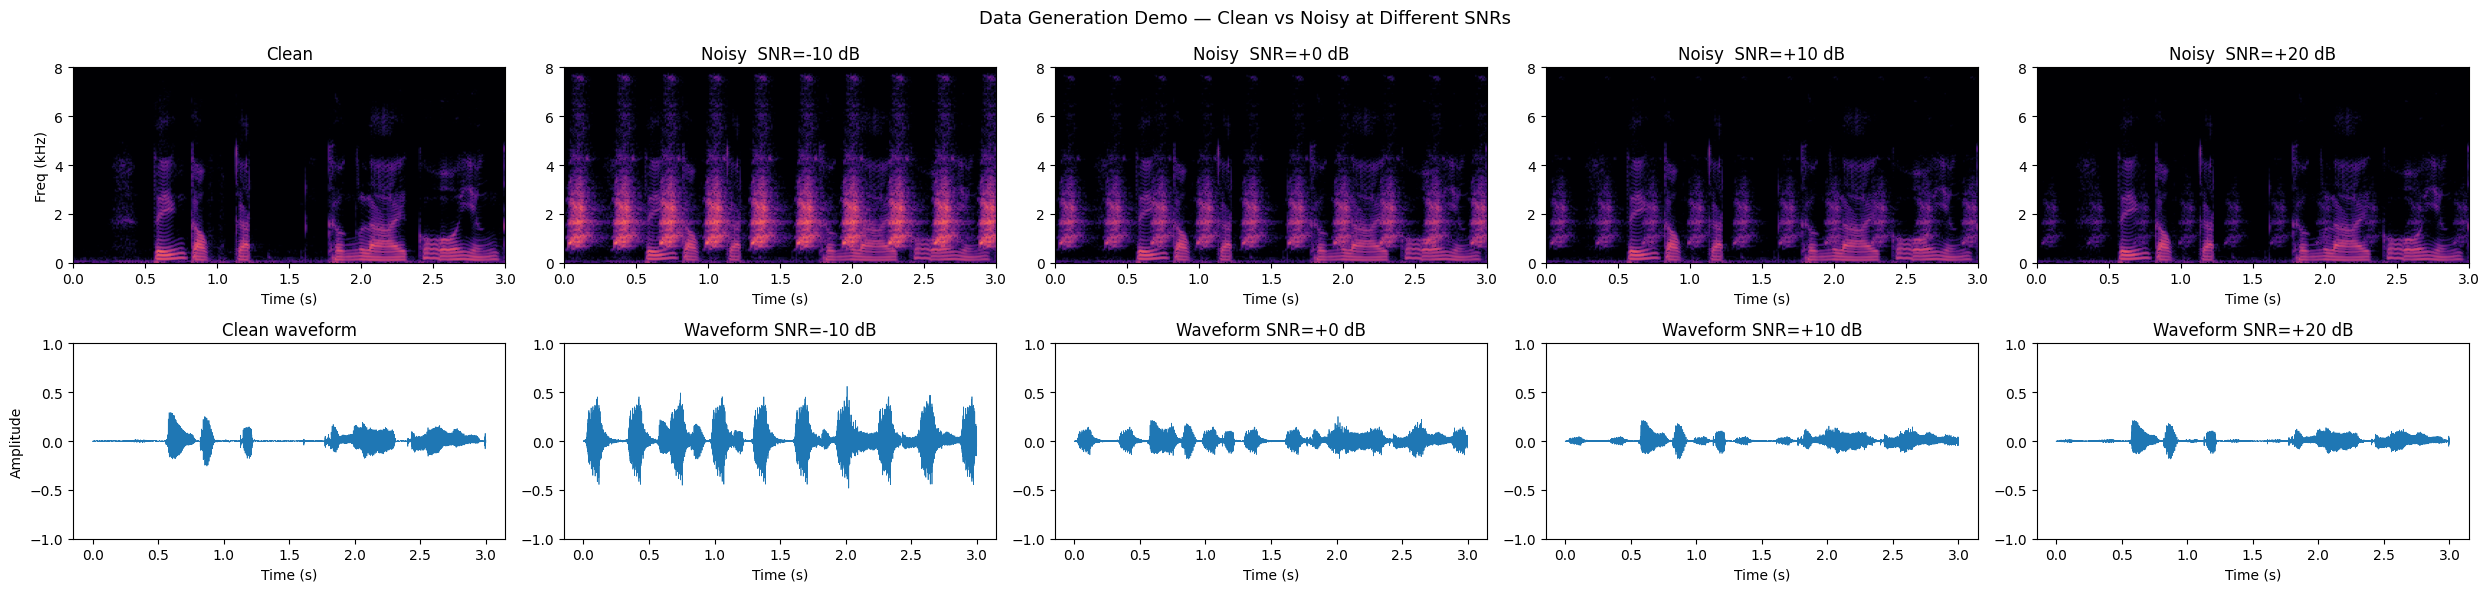

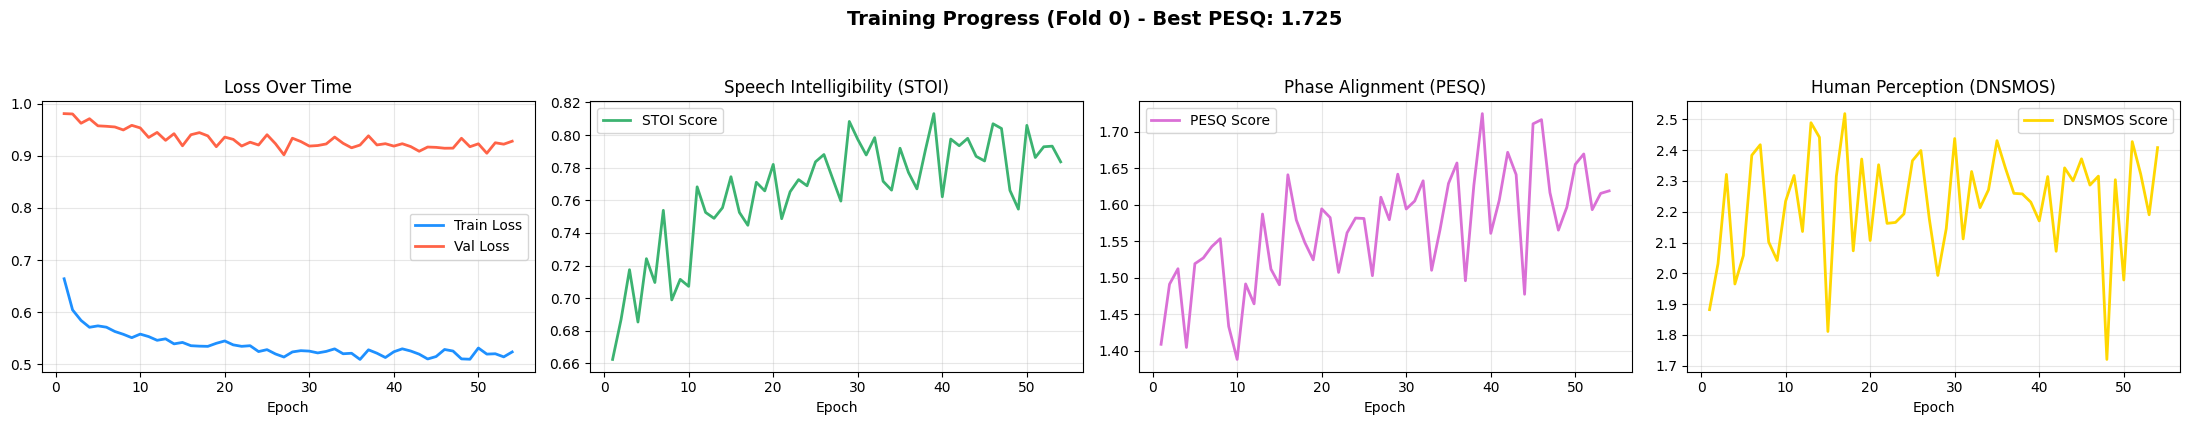

In [15]:
# ══════════════════════════════════════════════════════════════
# PLOT TRAINING HISTORY
# Run this cell anytime to visualize your progress!
# ══════════════════════════════════════════════════════════════
%matplotlib inline
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Load the saved histories directly from the hard drive
results_path = ROOT / 'manifests' / 'kfold_results_hybrid.json'

if not results_path.exists():
    print("No training data found yet! Let the training loop finish an epoch first.")
else:
    saved_results = json.loads(results_path.read_text())
    
    # Grab the current working fold (usually Fold 0 if you are just testing)
    current_fold = saved_results[-1] 
    ep = range(1, len(current_fold['train_loss_history']) + 1)

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Training Progress (Fold {current_fold['fold']}) - Best PESQ: {current_fold['best_pesq']:.3f}", 
                 fontsize=14, fontweight='bold', y=1.05)

    # 1. Loss Chart
    axes[0].plot(ep, current_fold['train_loss_history'], label='Train Loss', color='dodgerblue', lw=2)
    axes[0].plot(ep, current_fold['val_loss_history'], label='Val Loss', color='tomato', lw=2)
    axes[0].set_title('Loss Over Time')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 2. STOI Chart
    axes[1].plot(ep, current_fold['stoi_history'], label='STOI Score', color='mediumseagreen', lw=2)
    axes[1].set_title('Speech Intelligibility (STOI)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # 3. PESQ Chart
    axes[2].plot(ep, current_fold['pesq_history'], label='PESQ Score', color='orchid', lw=2)
    axes[2].set_title('Phase Alignment (PESQ)')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    # 4. DNSMOS Chart
    axes[3].plot(ep, current_fold['dnsmos_history'], label='DNSMOS Score', color='gold', lw=2)
    axes[3].set_title('Human Perception (DNSMOS)')
    axes[3].set_xlabel('Epoch')
    axes[3].legend()
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# K-FOLD SUMMARY + LOSS CURVES
# ══════════════════════════════════════════════════════════════
print('='*60)
print(f'K-Fold Summary  ({N_SPLITS} folds)')
print('='*60)
for r in fold_results:
    print(f"  Fold {r['fold']} | best_PESQ={r.get('best_pesq',0):.3f} | "
          f"train={r['train_size']} val={r['val_size']} test={r['test_size']}")

best_fold = max(fold_results, key=lambda x: x.get('best_pesq',0))
print(f"\nBest fold : {best_fold['fold']}  (best_PESQ={best_fold.get('best_pesq',0):.3f})")

results_path = ROOT/'manifests'/'kfold_results_hybrid.json'
results_path.write_text(json.dumps(fold_results, indent=2))
print(f"Results saved → {results_path}")

# ── Plot loss curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_SPLITS, figsize=(5*N_SPLITS, 4), sharey=True)
for r, ax in zip(fold_results, axes):
    ep = range(1, len(r['train_loss_history'])+1)
    ax.plot(ep, r['train_loss_history'], label='Train', lw=1.5)
    ax.plot(ep, r['val_loss_history'],   label='Val',   lw=1.5)
    ax.set_title(f"Fold {r['fold']}  best={r['best_pesq']:.4f}")
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Loss')
plt.suptitle('Training & Validation Loss — All Folds', fontsize=13)
plt.tight_layout()
curves_path = ROOT/'training_curves.png'
plt.savefig(str(curves_path), dpi=120, bbox_inches='tight')
plt.show()
print(f"Loss curves → {curves_path}")

In [ ]:
# ══════════════════════════════════════════════════════════════
# MODEL SPEED & ACCURACY BENCHMARK (Custom Run)
# Loads your 1.664 PESQ checkpoint, runs on test set, plots charts
# ══════════════════════════════════════════════════════════════
import pystoi
import time
from torch.cuda.amp import autocast

# ── 1. Load your manually saved best model ────────────────────────────────────
best_ckpt_path = Path(r"E:\0. Noise reduce\checkpoints\fold_0\best.pth")
state = torch.load(str(best_ckpt_path), map_location='cpu', weights_only=False)

saved_cfg   = state['model_cfg']
skip_props  = {'freq_bins','enc_out_ch'}
clean_kwargs= {k:v for k,v in saved_cfg.items() if k not in skip_props and not k.startswith('_')}

if 'enc_stages' in clean_kwargs:
    clean_kwargs['enc_stages'] = tuple(clean_kwargs['enc_stages'])

bench_cfg   = HybridDenoiserConfig(**clean_kwargs)
bench_model = HybridDenoiser(bench_cfg).eval()
bench_model.load_state_dict(state['model'], strict=True)

# THE FIX: Reparameterize FIRST, then send to GPU
bench_model.reparameterize()   
bench_model = bench_model.to(device)

print(f"Loaded high-score model : Epoch {state['epoch']} | Val Loss: {state['val_loss']:.4f}")

# ── 2. Build test loader (fold 0 test set) ────────────────────────────────────
fi0        = fold_indices[0]
test_clean = [clean_list[i] for i in fi0['test'][:200]]  # cap at 200 samples for a quick 1-minute test
test_ds    = NoiseSuppressionDataset(
    test_clean, noise_list, segment_len=SEG_LEN, sr=SR,
    mix_config=MIX_CFG, mode='val',
    manifest=fold_dir/'fold_0_test_manifest.jsonl',
    rir_cache=RIR_CACHE,
)
dl_kw = dict(batch_size=8, collate_fn=collate_audio, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
if NUM_WORKERS > 0:
    dl_kw['persistent_workers'] = True
    dl_kw['prefetch_factor']    = 2
_test_dl    = DataLoader(test_ds, shuffle=False, **dl_kw)
test_loader = ThreadedPrefetcher(_test_dl, device, queue_size=2)

# ── 3. Run benchmark ──────────────────────────────────────────────────────────
snr_in_all, snr_out_all, stoi_in_all, stoi_out_all = [], [], [], []
latencies_ms, rtf_all = [], []

print("Running 200-sample benchmark (this will take about 30 seconds)...", end=" ", flush=True)
with torch.no_grad():
    for bi, batch in enumerate(test_loader):
        if bi >= 25: break   # 25 batches × 8 = 200 samples
        clean = batch['clean']
        noisy = batch['noisy']
        wav_dur_s = clean.shape[-1] / SR

        # Latency measurement (GPU-sync)
        if device.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        
        with autocast(enabled=(device.type=='cuda')):
            pred, _, _ = bench_model(noisy)
            
        if device.type == 'cuda': torch.cuda.synchronize()
        elapsed_ms = (time.perf_counter() - t0) * 1000
        latencies_ms.append(elapsed_ms / clean.shape[0])  # per sample
        rtf_all.append((elapsed_ms/1000) / (wav_dur_s * clean.shape[0]))  # RTF

        min_l = min(pred.shape[-1], clean.shape[-1])
        pred_np  = pred[...,:min_l].float().cpu().numpy()
        clean_np = clean[...,:min_l].float().cpu().numpy()
        noisy_np = noisy[...,:min_l].float().cpu().numpy()

        for i in range(clean_np.shape[0]):
            c, p, n = clean_np[i], pred_np[i], noisy_np[i]
            snr_in_all.append(snr_db(c, n))
            snr_out_all.append(snr_db(c, p))
            try:
                stoi_in_all.append(pystoi.stoi(c, n, SR, extended=False))
                stoi_out_all.append(pystoi.stoi(c, p, SR, extended=False))
            except Exception: pass

print(f"done! ({len(snr_out_all)} samples evaluated)")

# ── 4. Print summary & Draw Charts ────────────────────────────────────────────
snri = np.array(snr_in_all);  snro = np.array(snr_out_all)
stoi_i=np.array(stoi_in_all); stoi_o=np.array(stoi_out_all)
lat   = np.array(latencies_ms); rtf = np.array(rtf_all)

print(f"\n{'='*52}")
print(f"  Metric               Input     Output    Δ")
print(f"{'─'*52}")
print(f"  SNR (dB)         {snri.mean():8.2f}  {snro.mean():8.2f}  {snro.mean()-snri.mean():+.2f}")
if len(stoi_o):
    print(f"  STOI             {stoi_i.mean():8.3f}  {stoi_o.mean():8.3f}  {stoi_o.mean()-stoi_i.mean():+.3f}")
print(f"{'─'*52}")
print(f"  Latency/sample   {lat.mean():8.1f} ms  (σ={lat.std():.1f})")
print(f"  RTF              {rtf.mean():8.4f}      (< 1.0 = real-time capable)")
print(f"{'='*52}")
real_time_ok = rtf.mean() < 1.0
print(f"  Real-time status : {'✓ YES' if real_time_ok else '✗ NO — needs optimisation'}")

# Charts
fig = plt.figure(figsize=(18, 12))
fig.suptitle('HybridDenoiser — Final Evaluation Benchmark', fontsize=16, y=1.02, fontweight='bold')

# 1. SNR scatter
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(snri, snro, alpha=0.4, s=15, c='dodgerblue')
lims = [min(snri.min(),snro.min())-2, max(snri.max(),snro.max())+2]
ax1.plot(lims, lims, 'r--', lw=2, label='no change (0 dB Δ)')
ax1.set_xlabel('Input SNR (dB)', fontweight='bold')
ax1.set_ylabel('Output SNR (dB)', fontweight='bold')
ax1.set_title('Signal-to-Noise Ratio: Input vs Output')
ax1.legend(); ax1.grid(alpha=0.3)

# 2. SNR improvement histogram
ax2 = fig.add_subplot(2, 3, 2)
snr_improvement = snro - snri
ax2.hist(snr_improvement, bins=25, color='dodgerblue', edgecolor='white')
ax2.axvline(snr_improvement.mean(), color='red', lw=2.5, label=f'Mean Δ = +{snr_improvement.mean():.2f} dB')
ax2.set_xlabel('Δ SNR Improvement (dB)', fontweight='bold')
ax2.set_ylabel('Number of Audio Files', fontweight='bold')
ax2.set_title('Overall SNR Improvement Distribution')
ax2.legend(); ax2.grid(alpha=0.3)

# 3. STOI bar chart
ax3 = fig.add_subplot(2, 3, 3)
if len(stoi_o):
    labels = ['Noisy Audio (Input)', 'AI Denoised (Output)']
    values = [stoi_i.mean(), stoi_o.mean()]
    errs   = [stoi_i.std(),  stoi_o.std()]
    bars   = ax3.bar(labels, values, color=['tomato','dodgerblue'], alpha=0.8, edgecolor='black', width=0.6)
    ax3.errorbar(labels, values, yerr=errs, fmt='none', color='black', capsize=6, lw=2)
    ax3.set_ylim(0, 1.05); ax3.set_ylabel('STOI Score (0 to 1.0)', fontweight='bold')
    ax3.set_title('Speech Intelligibility (STOI) Recovery')
    for bar, v in zip(bars, values):
        ax3.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)
    ax3.grid(axis='y', alpha=0.3)

# 4. Latency distribution
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(lat, bins=20, color='mediumseagreen', edgecolor='white')
ax4.axvline(lat.mean(), color='red', lw=2.5, label=f'Mean Latency = {lat.mean():.1f} ms')
ax4.set_xlabel('GPU Inference Latency per Sample (ms)', fontweight='bold')
ax4.set_ylabel('Number of Audio Files', fontweight='bold')
ax4.set_title('Model Speed & Responsiveness')
ax4.legend(); ax4.grid(alpha=0.3)

# 5. RTF bar + real-time line
ax5 = fig.add_subplot(2, 3, 5)
ax5.bar(['Average RTF','Worst-Case (Max) RTF'], [rtf.mean(), rtf.max()],
         color=['mediumseagreen','tomato'], alpha=0.8, edgecolor='black', width=0.6)
ax5.axhline(1.0, color='red', lw=2.5, ls='--', label='1.0 Real-Time Limit')
ax5.set_ylabel('RTF (Lower is Faster)', fontweight='bold')
ax5.set_title('Real-Time Factor (RTF)')
ax5.legend(); ax5.grid(axis='y', alpha=0.3)

# 6. Spectrogram example
ax6 = fig.add_subplot(2, 3, 6)
with torch.no_grad():
    sample_batch = next(iter(DataLoader(test_ds, batch_size=1, collate_fn=collate_audio)))
    s_clean = sample_batch['clean'].to(device)
    s_noisy = sample_batch['noisy'].to(device)
    with autocast(enabled=(device.type=='cuda')):
        s_pred, _, _ = bench_model(s_noisy)

import scipy.signal
def _spec_db(wav_np):
    _,_,Z = scipy.signal.stft(wav_np, fs=SR, nperseg=400, noverlap=240, nfft=512)
    return 20*np.log10(np.abs(Z)+1e-8)

c_np = s_clean[0].float().cpu().numpy()
n_np = s_noisy[0].float().cpu().numpy()
p_np = s_pred[0,...,:c_np.shape[-1]].float().cpu().numpy()

combined = np.concatenate([_spec_db(n_np), _spec_db(p_np), _spec_db(c_np)], axis=1)
ax6.imshow(combined, origin='lower', aspect='auto', vmin=-80, vmax=0, cmap='magma')
T = combined.shape[1]
ax6.axvline(T//3,   color='white', lw=2, ls='--')
ax6.axvline(2*T//3, color='white', lw=2, ls='--')

# Adding text labels directly onto the spectrograms for the report
ax6.text(T//6, 200, 'NOISY INPUT', color='white', fontweight='bold', ha='center', fontsize=10, backgroundcolor='black')
ax6.text(T//2, 200, 'AI DENOISED', color='white', fontweight='bold', ha='center', fontsize=10, backgroundcolor='black')
ax6.text(5*T//6, 200, 'CLEAN TARGET', color='white', fontweight='bold', ha='center', fontsize=10, backgroundcolor='black')

ax6.set_title('Spectrogram Visual Proof')
ax6.set_xlabel('Time', fontweight='bold')
ax6.set_ylabel('Frequency Bins', fontweight='bold')

plt.tight_layout()
bench_path = ROOT/'benchmark_results.png'
plt.savefig(str(bench_path), dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ High-res chart saved for your report: {bench_path}")

In [ ]:
# ══════════════════════════════════════════════════════════════
# EXPORT — TorchScript + ONNX
# ══════════════════════════════════════════════════════════════

class ExportWrapper(nn.Module):
    def __init__(self,m): super().__init__(); self.m=m
    def forward(self,wav): denoised,_,_=self.m(wav); return denoised

bench_model.cpu().eval()
wrapper = ExportWrapper(bench_model).eval()
example = torch.randn(1, 64000)   # 4 s at 16 kHz

export_dir = ROOT/'checkpoints'
export_dir.mkdir(parents=True, exist_ok=True)

# TorchScript
ts_path = export_dir/'hybrid_denoiser_best.ts'
ts = torch.jit.trace(wrapper,(example,))
ts.save(str(ts_path))
print(f"TorchScript → {ts_path}")



In [ ]:
# ══════════════════════════════════════════════════════════════
# FULL METRICS REPORT — All Folds
# Run this cell after all folds complete to see every metric
# ══════════════════════════════════════════════════════════════
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r"E:\0. Noise reduce")

# ── Load results from disk (works even if kernel was restarted) ───────────────
results_path = ROOT / 'manifests' / 'kfold_results_hybrid.json'
if results_path.exists():
    fold_results = json.loads(results_path.read_text())
    print(f"Loaded results from {results_path}")
else:
    print("[using in-memory fold_results]")

# ── Load per-fold val metrics from each checkpoint ────────────────────────────
print("\nLoading best checkpoint per fold and re-evaluating...\n")

fold_metrics = []
for r in fold_results:
    ckpt_path = Path(r['checkpoint'])
    if not ckpt_path.exists():
        print(f"  [skip] Fold {r['fold']} — checkpoint not found: {ckpt_path}")
        continue

    state = torch.load(str(ckpt_path), map_location=device, weights_only=False)
    saved_cfg = state['model_cfg']
    if 'enc_stages' in saved_cfg:
        saved_cfg['enc_stages'] = tuple(saved_cfg['enc_stages'])
    skip = {'freq_bins', 'enc_out_ch'}
    cfg_kwargs = {k:v for k,v in saved_cfg.items() if k not in skip and not k.startswith('_')}
    m = HybridDenoiser(HybridDenoiserConfig(**cfg_kwargs)).to(device)
    m.load_state_dict(state['model'], strict=True)

    # Build val loader for this fold
    fi        = fold_indices[r['fold']]
    tv_idx    = fi['train_val']
    val_sz    = max(1, len(tv_idx) // 5)
    val_idx   = tv_idx[-val_sz:]
    val_clean = [clean_list[i] for i in val_idx]
    val_manifest = fold_dir / f"fold_{r['fold']}_val_manifest.jsonl"

    val_ds = NoiseSuppressionDataset(
        val_clean, noise_list,
        segment_len=SEG_LEN, sr=SR,
        mix_config=MIX_CFG, mode='val',
        manifest=val_manifest, rir_cache=RIR_CACHE,
    )
    val_loader = DataLoader(val_ds, batch_size=8, shuffle=False,
                            collate_fn=collate_audio, num_workers=0)
    criterion_eval = HybridLoss(tap_reg_weight=1e-4).to(device)

    metrics = compute_val_metrics(m, val_loader, criterion_eval, device, max_batches=30)
    metrics['fold']       = r['fold']
    metrics['best_pesq']  = state.get('best_pesq', 0.0)
    metrics['checkpoint'] = str(ckpt_path)
    fold_metrics.append(metrics)

    print(f"  Fold {r['fold']} | "
          f"pesq={metrics['pesq']:.3f}  "
          f"dnsmos={metrics['dnsmos_ovr']:.3f}  "
          f"stoi={metrics['stoi']:.3f}  "
          f"sim={metrics['sim']:.3f}  "
          f"corr={metrics['corr']:.3f}  "
          f"snr={metrics['snr_spec']:.2f}dB  "
          f"dist={metrics['spec_dist']:.2f}  "
          f"mae={metrics['mae']:.3f}")

    del m
    torch.cuda.empty_cache()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*80)
print(f"{'Metric':<14}", end="")
for r in fold_metrics:
    print(f"  Fold {r['fold']:<6}", end="")
print(f"  {'Mean':<8}  {'Std':<8}")
print("="*80)

metric_list = [
    ('pesq',       'PESQ',        '{:.3f}'),
    ('dnsmos_ovr', 'DNSMOS ovr',  '{:.3f}'),
    ('dnsmos_sig', 'DNSMOS sig',  '{:.3f}'),
    ('dnsmos_bak', 'DNSMOS bak',  '{:.3f}'),
    ('stoi',       'STOI',        '{:.3f}'),
    ('sim',        'Similarity',  '{:.3f}'),
    ('corr',       'Correlation', '{:.3f}'),
    ('snr_spec',   'SNR (dB)',    '{:.2f}'),
    ('spec_dist',  'Spec Dist',   '{:.2f}'),
    ('mae',        'MAE',         '{:.3f}'),
    ('total',      'Val Loss',    '{:.4f}'),
]

for key, label, fmt in metric_list:
    vals = [r[key] for r in fold_metrics]
    mean = np.mean(vals)
    std  = np.std(vals)
    print(f"{label:<14}", end="")
    for v in vals:
        print(f"  {fmt.format(v):<8}", end="")
    print(f"  {fmt.format(mean):<8}  {fmt.format(std):<8}")

print("="*80)

best = max(fold_metrics, key=lambda x: x['pesq'])
print(f"\nBest fold by PESQ : Fold {best['fold']}  "
      f"(PESQ={best['pesq']:.3f}  DNSMOS={best['dnsmos_ovr']:.3f})")
print(f"Checkpoint        : {best['checkpoint']}")

# ── Chart: all metrics per fold ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('All Metrics — Per Fold', fontsize=15)

chart_metrics = [
    ('pesq',       'PESQ (1–4.5)',      'steelblue'),
    ('dnsmos_ovr', 'DNSMOS Overall',    'mediumseagreen'),
    ('stoi',       'STOI (0–1)',         'coral'),
    ('sim',        'Cosine Similarity', 'orchid'),
    ('corr',       'Pearson Corr',      'gold'),
    ('snr_spec',   'Spectral SNR (dB)', 'tomato'),
    ('spec_dist',  'Spec Distortion',   'slategray'),
    ('mae',        'MAE',               'peru'),
]

fold_labels = [f"Fold {r['fold']}" for r in fold_metrics]

for ax, (key, label, color) in zip(axes.flatten(), chart_metrics):
    vals = [r[key] for r in fold_metrics]
    mean = np.mean(vals)
    bars = ax.bar(fold_labels, vals, color=color, alpha=0.8, edgecolor='black')
    ax.axhline(mean, color='red', lw=2, ls='--', label=f'Mean={mean:.3f}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
report_path = ROOT / 'fold_metrics_report.png'
plt.savefig(str(report_path), dpi=130, bbox_inches='tight')
plt.show()
print(f"\nChart saved → {report_path}")

In [ ]:
"""import librosa
import soundfile as sf
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def resample_and_filter_urbansound(input_dir, output_dir, target_sr=16000):
    in_dir = Path(input_dir)
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # The safe classes for speech denoising
    # 0: air_conditioner, 1: car_horn, 3: dog_bark, 4: drilling, 
    # 5: engine_idling, 7: jackhammer, 8: siren
    safe_classes = {"0", "1", "3", "4", "5", "7", "8"}
    
    exts = {".wav", ".flac", ".ogg", ".mp3", ".m4a"}
    files = [p for p in in_dir.rglob("*") if p.is_file() and p.suffix.lower() in exts]
    
    safe_files = []
    for f in files:
        # UrbanSound filenames look like: 100263-2-0-117.wav
        # We split by '-' and grab the second item (the class ID)
        parts = f.name.split('-')
        if len(parts) >= 2 and parts[1] in safe_classes:
            safe_files.append(f)

    print(f"Found {len(files)} total files.")
    print(f"Filtered down to {len(safe_files)} SAFE noise files.")
    print(f"Converting to {target_sr}Hz Mono...")
    
    for f in tqdm(safe_files):
        try:
            y, _ = librosa.load(f, sr=target_sr, mono=True)
            # Flatten the folder structure so they all go straight into noise_16k
            save_path = out_dir / f.name
            save_path = save_path.with_suffix('.wav')
            sf.write(save_path, y, target_sr, subtype='PCM_16')
        except Exception as e:
            pass # Skip corrupted audio files if any

    print(f"Done! Safe noises saved to: {out_dir}")

# RUN THE FILTER & RESAMPLER
# Make sure the input_dir points to the folder containing fold1, fold2, etc.
resample_and_filter_urbansound(
    input_dir=r"D:\Download\DNS-Challenge\archive", 
    output_dir=r"E:\0. Noise reduce\data\noise_16k"
)
"""

In [ ]:
import IPython.display as ipd
import torch
from pathlib import Path

# 1. Load your saved high-score model directly from the hard drive
ckpt_path = Path(r"E:\0. Noise reduce\checkpoints\fold_0\best.pth")
state = torch.load(ckpt_path, map_location=device, weights_only=False)

# Rebuild the model blueprint
saved_cfg = state['model_cfg']
if 'enc_stages' in saved_cfg: saved_cfg['enc_stages'] = tuple(saved_cfg['enc_stages'])
clean_kwargs = {k:v for k,v in saved_cfg.items() if k not in {'freq_bins','enc_out_ch'} and not k.startswith('_')}

test_model = HybridDenoiser(HybridDenoiserConfig(**clean_kwargs))
test_model.load_state_dict(state['model'], strict=True)
test_model.eval()

# THE FIX: Reparameterize FIRST, then send the finalized model to the GPU!
test_model.reparameterize() 
test_model = test_model.to(device)

# 2. Grab a random test batch
sample_batch = next(iter(val_loader)) 
s_clean = sample_batch['clean'][0:1].to(device)
s_noisy = sample_batch['noisy'][0:1].to(device)

# 3. Run the AI! (Standard precision, no autocast needed for a single file)
with torch.no_grad():
    s_pred, _, _ = test_model(s_noisy)

# 4. Move audio to CPU for playback
clean_audio = s_clean[0].cpu().numpy()
noisy_audio = s_noisy[0].cpu().numpy()
ai_audio = s_pred[0].cpu().numpy()

# 5. Display the audio players
print("🎧 1. ORIGINAL NOISY AUDIO:")
display(ipd.Audio(noisy_audio, rate=16000))

print("\n🎧 2. CLEAN TARGET (What the AI is trying to match):")
display(ipd.Audio(clean_audio, rate=16000))

print("\n🎧 3. AI DENOISED AUDIO (PESQ 1.664):")
display(ipd.Audio(ai_audio, rate=16000))